In [ ]:
from pathlib import Path
import json
import urllib.request
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    try:
        import ipykernel

        connection_file = Path(ipykernel.get_connection_file()).name
        kernel_id = connection_file.split('-', 1)[1].split('.', 1)[0]

        try:
            from notebook import notebookapp

            servers = list(notebookapp.list_running_servers())
        except Exception:
            from jupyter_server import serverapp

            servers = list(serverapp.list_running_servers())

        for srv in servers:
            token = srv.get('token', '')
            api_url = f"{srv['url'].rstrip('/')}/api/sessions"
            if token:
                api_url = f"{api_url}?token={token}"

            with urllib.request.urlopen(api_url, timeout=2) as response:
                sessions = json.loads(response.read().decode('utf-8'))

            for sess in sessions:
                if sess.get('kernel', {}).get('id') == kernel_id:
                    notebook_path = sess.get('notebook', {}).get('path') or sess.get('path', '')
                    raw_stem = Path(notebook_path).stem or 'notebook'
                    safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
                    return safe_stem.strip('_') or 'notebook'
    except Exception:
        pass

    return 'notebook'


if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1
    plt._trebl_notebook_stem = _trebl_notebook_stem()

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


# Composition and sequence models for GCN4 speed and strength

This notebook compares a small set of regression models for predicting **speed** and **strength** from the GCN4 activation domain sequence. The requested baselines are included explicitly:

- **linear regression on amino-acid composition**
- **linear regression on one-hot encoded sequence identity**

To see whether less interpretable models help, the notebook also benchmarks a few additional regressors on the same train/test split and 5-fold cross-validation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from scipy.stats import pearsonr
from IPython.display import display

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_context('talk')
sns.set_style('white')
RANDOM_STATE = 42
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')


## Load the fitted speed and strength values


In [2]:
exponential_fit = pd.read_csv('../../../output/GCN4_pipeline/speed/exponential_fit.csv', index_col=0)
exponential_fit = exponential_fit[['ADseq', 'A+C', 'k']].rename(
    columns={'A+C': 'strength', 'k': 'speed'}
)

exponential_fit.head()

,ADseq,strength,speed
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,4.150082,0.115100
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.986402,0.074620
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.129853,0.146610
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.706721,0.159460
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.630930,0.155566


,mean,std,min,max,n_sequences
speed,0.138412,0.053018,0.019366,0.583590,4107
strength,2.851608,1.227419,0.041809,8.064008,4107


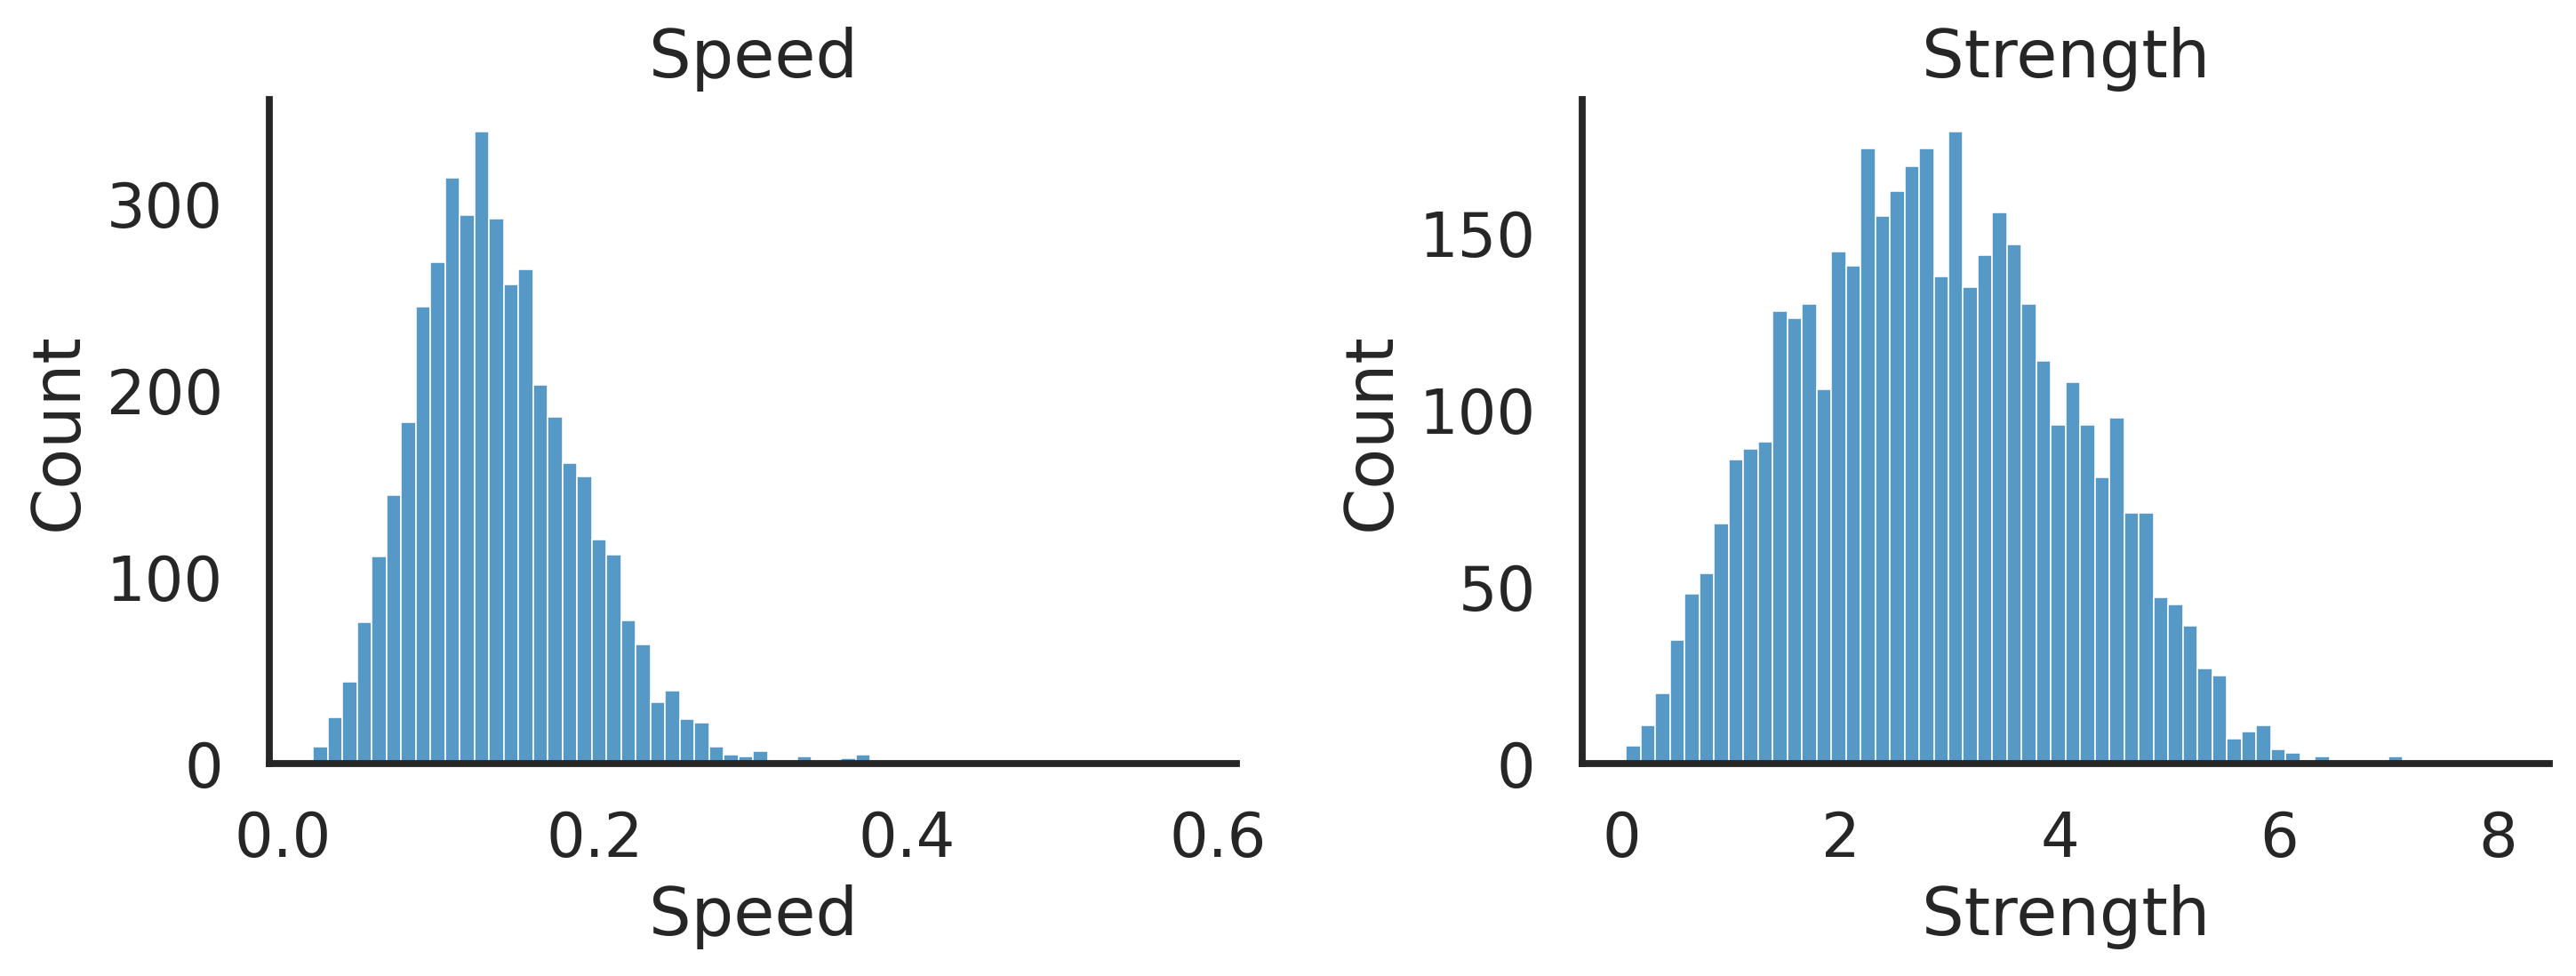

In [3]:
summary_df = exponential_fit[['speed', 'strength']].agg(['mean', 'std', 'min', 'max']).T
summary_df['n_sequences'] = len(exponential_fit)
display(summary_df)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=300)
for ax, column in zip(axs, ['speed', 'strength']):
    sns.histplot(exponential_fit[column], bins=60, ax=ax)
    ax.set_title(column.capitalize())
    ax.set_xlabel(column.capitalize())
    ax.set_ylabel('Count')

sns.despine()
plt.tight_layout()

## Shared feature engineering and evaluation helpers


In [4]:
def aa_composition(seq):
    counts = Counter(seq)
    length = len(seq)
    return {aa: counts.get(aa, 0) / length for aa in AMINO_ACIDS}


def build_one_hot_features(seqs):
    seq_lengths = pd.Series(seqs).str.len()
    assert seq_lengths.nunique() == 1, 'Sequences must all have the same length'
    seq_length = int(seq_lengths.iloc[0])

    aa_to_idx = {aa: idx for idx, aa in enumerate(AMINO_ACIDS)}
    feature_names = [
        f'pos{pos + 1:02d}_{aa}'
        for pos in range(seq_length)
        for aa in AMINO_ACIDS
    ]

    encoded = np.zeros((len(seqs), seq_length * len(AMINO_ACIDS)), dtype=np.float32)
    for row_idx, seq in enumerate(seqs):
        for pos, aa in enumerate(seq):
            if aa not in aa_to_idx:
                raise ValueError(f'Unexpected amino acid {aa!r} in sequence {seq!r}')
            encoded[row_idx, pos * len(AMINO_ACIDS) + aa_to_idx[aa]] = 1.0

    return pd.DataFrame(encoded, columns=feature_names), seq_length


def safe_pearson(y_true, y_pred):
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return pearsonr(y_true, y_pred)[0]


def metric_row(y_true, y_pred, feature_set, target_name, model_name, split_name):
    return {
        'feature_set': feature_set,
        'target': target_name,
        'model': model_name,
        'split': split_name,
        'r2': r2_score(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'pearson_r': safe_pearson(y_true, y_pred),
    }


def evaluate_model(builder, X, y, feature_set, target_name, train_idx, test_idx, cv):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    estimator = builder()
    estimator.fit(X_train, y_train)
    y_test_pred = estimator.predict(X_test)

    cv_estimator = builder()
    y_cv_pred = cross_val_predict(cv_estimator, X, y, cv=cv)

    summary_rows = [
        metric_row(y_test, y_test_pred, feature_set, target_name, estimator.__class__.__name__, 'holdout'),
        metric_row(y, y_cv_pred, feature_set, target_name, estimator.__class__.__name__, '5-fold CV'),
    ]

    return summary_rows, {
        'estimator': estimator,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'y_cv_pred': y_cv_pred,
    }


def benchmark_models(X, targets, model_builders, feature_set, train_idx, test_idx, cv):
    rows = []
    artifacts = {}
    for target_name, y in targets.items():
        for model_name, builder in model_builders.items():
            summary_rows, artifact = evaluate_model(
                builder, X, y, feature_set, target_name, train_idx, test_idx, cv
            )
            for row in summary_rows:
                row['model'] = model_name
            rows.extend(summary_rows)
            artifacts[(feature_set, target_name, model_name)] = artifact
    return pd.DataFrame(rows), artifacts


def coefficient_table(model, feature_names, n=12):
    coef = np.asarray(model.coef_).reshape(-1)
    coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
    coef_df['abs_coef'] = coef_df['coef'].abs()
    return coef_df.sort_values('abs_coef', ascending=False).head(n)


def plot_prediction_grid(artifacts, feature_set, model_name, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300, sharex=False, sharey=False)
    for ax, target_name in zip(axes, ['speed', 'strength']):
        artifact = artifacts[(feature_set, target_name, model_name)]
        y_true = artifact['y_test']
        y_pred = artifact['y_test_pred']
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='none')
        ax.plot(lims, lims, 'r--', lw=1)
        ax.set_title(
            f"{target_name.capitalize()}\nR²={r2_score(y_true, y_pred):.2f}, r={safe_pearson(y_true, y_pred):.2f}"
        )
        ax.set_xlabel('Observed')
        ax.set_ylabel('Predicted')
    fig.suptitle(f'GCN4 {title_prefix}: {model_name}', y=0.95)
    sns.despine()
    plt.tight_layout()


## Build the composition and one-hot feature sets


In [5]:
composition_df = pd.DataFrame(exponential_fit['ADseq'].apply(aa_composition).tolist())
onehot_df, seq_length = build_one_hot_features(exponential_fit['ADseq'])

targets = {
    'speed': exponential_fit['speed'].to_numpy(),
    'strength': exponential_fit['strength'].to_numpy(),
}

train_idx, test_idx = train_test_split(
    np.arange(len(exponential_fit)), test_size=0.2, random_state=RANDOM_STATE
)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pd.DataFrame({
    'feature_set': ['composition', 'one_hot_sequence'],
    'n_samples': [len(composition_df), len(onehot_df)],
    'n_features': [composition_df.shape[1], onehot_df.shape[1]],
    'sequence_length': [seq_length, seq_length],
})


,feature_set,n_samples,n_features,sequence_length
0,composition,4107,20,40
1,one_hot_sequence,4107,800,40


## Linear and ridge-regression baselines

This section benchmarks ordinary least-squares (**Linear regression**) and **Ridge regression** on both feature spaces:
- amino-acid **composition**
- **one-hot encoded sequence**


In [6]:
linear_models = {'Linear regression': lambda: LinearRegression()}
ridge_alphas = np.logspace(-4, 4, 81)
ridge_models = {'Ridge regression': lambda: RidgeCV(alphas=ridge_alphas)}

composition_linear_summary, composition_linear_artifacts = benchmark_models(
    composition_df, targets, linear_models, 'composition', train_idx, test_idx, cv
)
onehot_linear_summary, onehot_linear_artifacts = benchmark_models(
    onehot_df, targets, linear_models, 'one_hot_sequence', train_idx, test_idx, cv
)

composition_ridge_summary, composition_ridge_artifacts = benchmark_models(
    composition_df, targets, ridge_models, 'composition', train_idx, test_idx, cv
)
onehot_ridge_summary, onehot_ridge_artifacts = benchmark_models(
    onehot_df, targets, ridge_models, 'one_hot_sequence', train_idx, test_idx, cv
)

model_summary = (
    pd.concat(
        [
            composition_linear_summary,
            onehot_linear_summary,
            composition_ridge_summary,
            onehot_ridge_summary,
        ],
        ignore_index=True,
    )
    .sort_values(['split', 'target', 'model', 'r2'], ascending=[True, True, True, False])
    .reset_index(drop=True)
)

display(model_summary)

ridge_alpha_rows = []
for feature_set, artifacts in [
    ('composition', composition_ridge_artifacts),
    ('one_hot_sequence', onehot_ridge_artifacts),
]:
    for target_name in ['speed', 'strength']:
        ridge_alpha_rows.append(
            {
                'feature_set': feature_set,
                'target': target_name,
                'selected_alpha': artifacts[(feature_set, target_name, 'Ridge regression')]['estimator'].alpha_,
            }
        )

display(pd.DataFrame(ridge_alpha_rows))


,feature_set,target,model,split,r2,rmse,pearson_r
0,composition,speed,Linear regression,5-fold CV,0.206588,0.047220,0.454677
1,one_hot_sequence,speed,Linear regression,5-fold CV,0.062737,0.051322,0.396242
2,composition,speed,Ridge regression,5-fold CV,0.206515,0.047222,0.454505
3,one_hot_sequence,speed,Ridge regression,5-fold CV,0.171825,0.048243,0.414676
4,composition,strength,Linear regression,5-fold CV,0.545353,0.827517,0.738498
5,one_hot_sequence,strength,Linear regression,5-fold CV,0.485107,0.880640,0.713435
6,composition,strength,Ridge regression,5-fold CV,0.545378,0.827495,0.738501
7,one_hot_sequence,strength,Ridge regression,5-fold CV,0.508584,0.860329,0.715248
8,composition,speed,Linear regression,holdout,0.198674,0.048000,0.446760
9,one_hot_sequence,speed,Linear regression,holdout,0.082433,0.051364,0.403580


,feature_set,target,selected_alpha
0,composition,speed,0.031623
1,composition,strength,0.007943
2,one_hot_sequence,speed,125.892541
3,one_hot_sequence,strength,10.000000


Top composition coefficients for speed (Linear regression)


,feature,coef,abs_coef
18,W,0.463744,0.463744
1,C,-0.386702,0.386702
4,F,0.362833,0.362833
2,D,0.244724,0.244724
14,R,-0.194331,0.194331
10,M,0.167706,0.167706
8,K,-0.149980,0.149980
17,V,-0.149239,0.149239
0,A,-0.132637,0.132637
11,N,-0.088427,0.088427


Top composition coefficients for strength (Linear regression)


,feature,coef,abs_coef
18,W,21.750742,21.750742
4,F,13.577457,13.577457
8,K,-11.806883,11.806883
14,R,-10.778363,10.778363
10,M,10.333181,10.333181
6,H,-7.537108,7.537108
13,Q,-5.967586,5.967586
9,L,5.827394,5.827394
19,Y,5.086176,5.086176
5,G,-4.798314,4.798314


Top one_hot_sequence coefficients for speed (Linear regression)


...

,feature,coef,abs_coef
18,W,21.326774,21.326774
4,F,13.500145,13.500145
8,K,-11.671829,11.671829
14,R,-10.747956,10.747956
10,M,10.233754,10.233754
6,H,-7.481324,7.481324
13,Q,-5.918793,5.918793
9,L,5.786940,5.786940
19,Y,5.028144,5.028144
5,G,-4.739205,4.739205


Top one_hot_sequence coefficients for speed (Ridge regression)


,feature,coef,abs_coef
144,pos08_F,0.009391,0.009391
784,pos40_F,0.008449,0.008449
302,pos16_D,0.008228,0.008228
282,pos15_D,0.007957,0.007957
182,pos10_D,0.007880,0.007880
224,pos12_F,0.007757,0.007757
442,pos23_D,0.007606,0.007606
154,pos08_R,-0.007461,0.007461
623,pos32_E,0.007241,0.007241
342,pos18_D,0.007070,0.007070


Top one_hot_sequence coefficients for strength (Ridge regression)


,feature,coef,abs_coef
658,pos33_W,0.516841,0.516841
478,pos24_W,0.513783,0.513783
278,pos14_W,0.507186,0.507186
678,pos34_W,0.500689,0.500689
298,pos15_W,0.478991,0.478991
698,pos35_W,0.468840,0.468840
530,pos27_M,0.429690,0.429690
398,pos20_W,0.428368,0.428368
288,pos15_K,-0.424962,0.424962
518,pos26_W,0.418899,0.418899


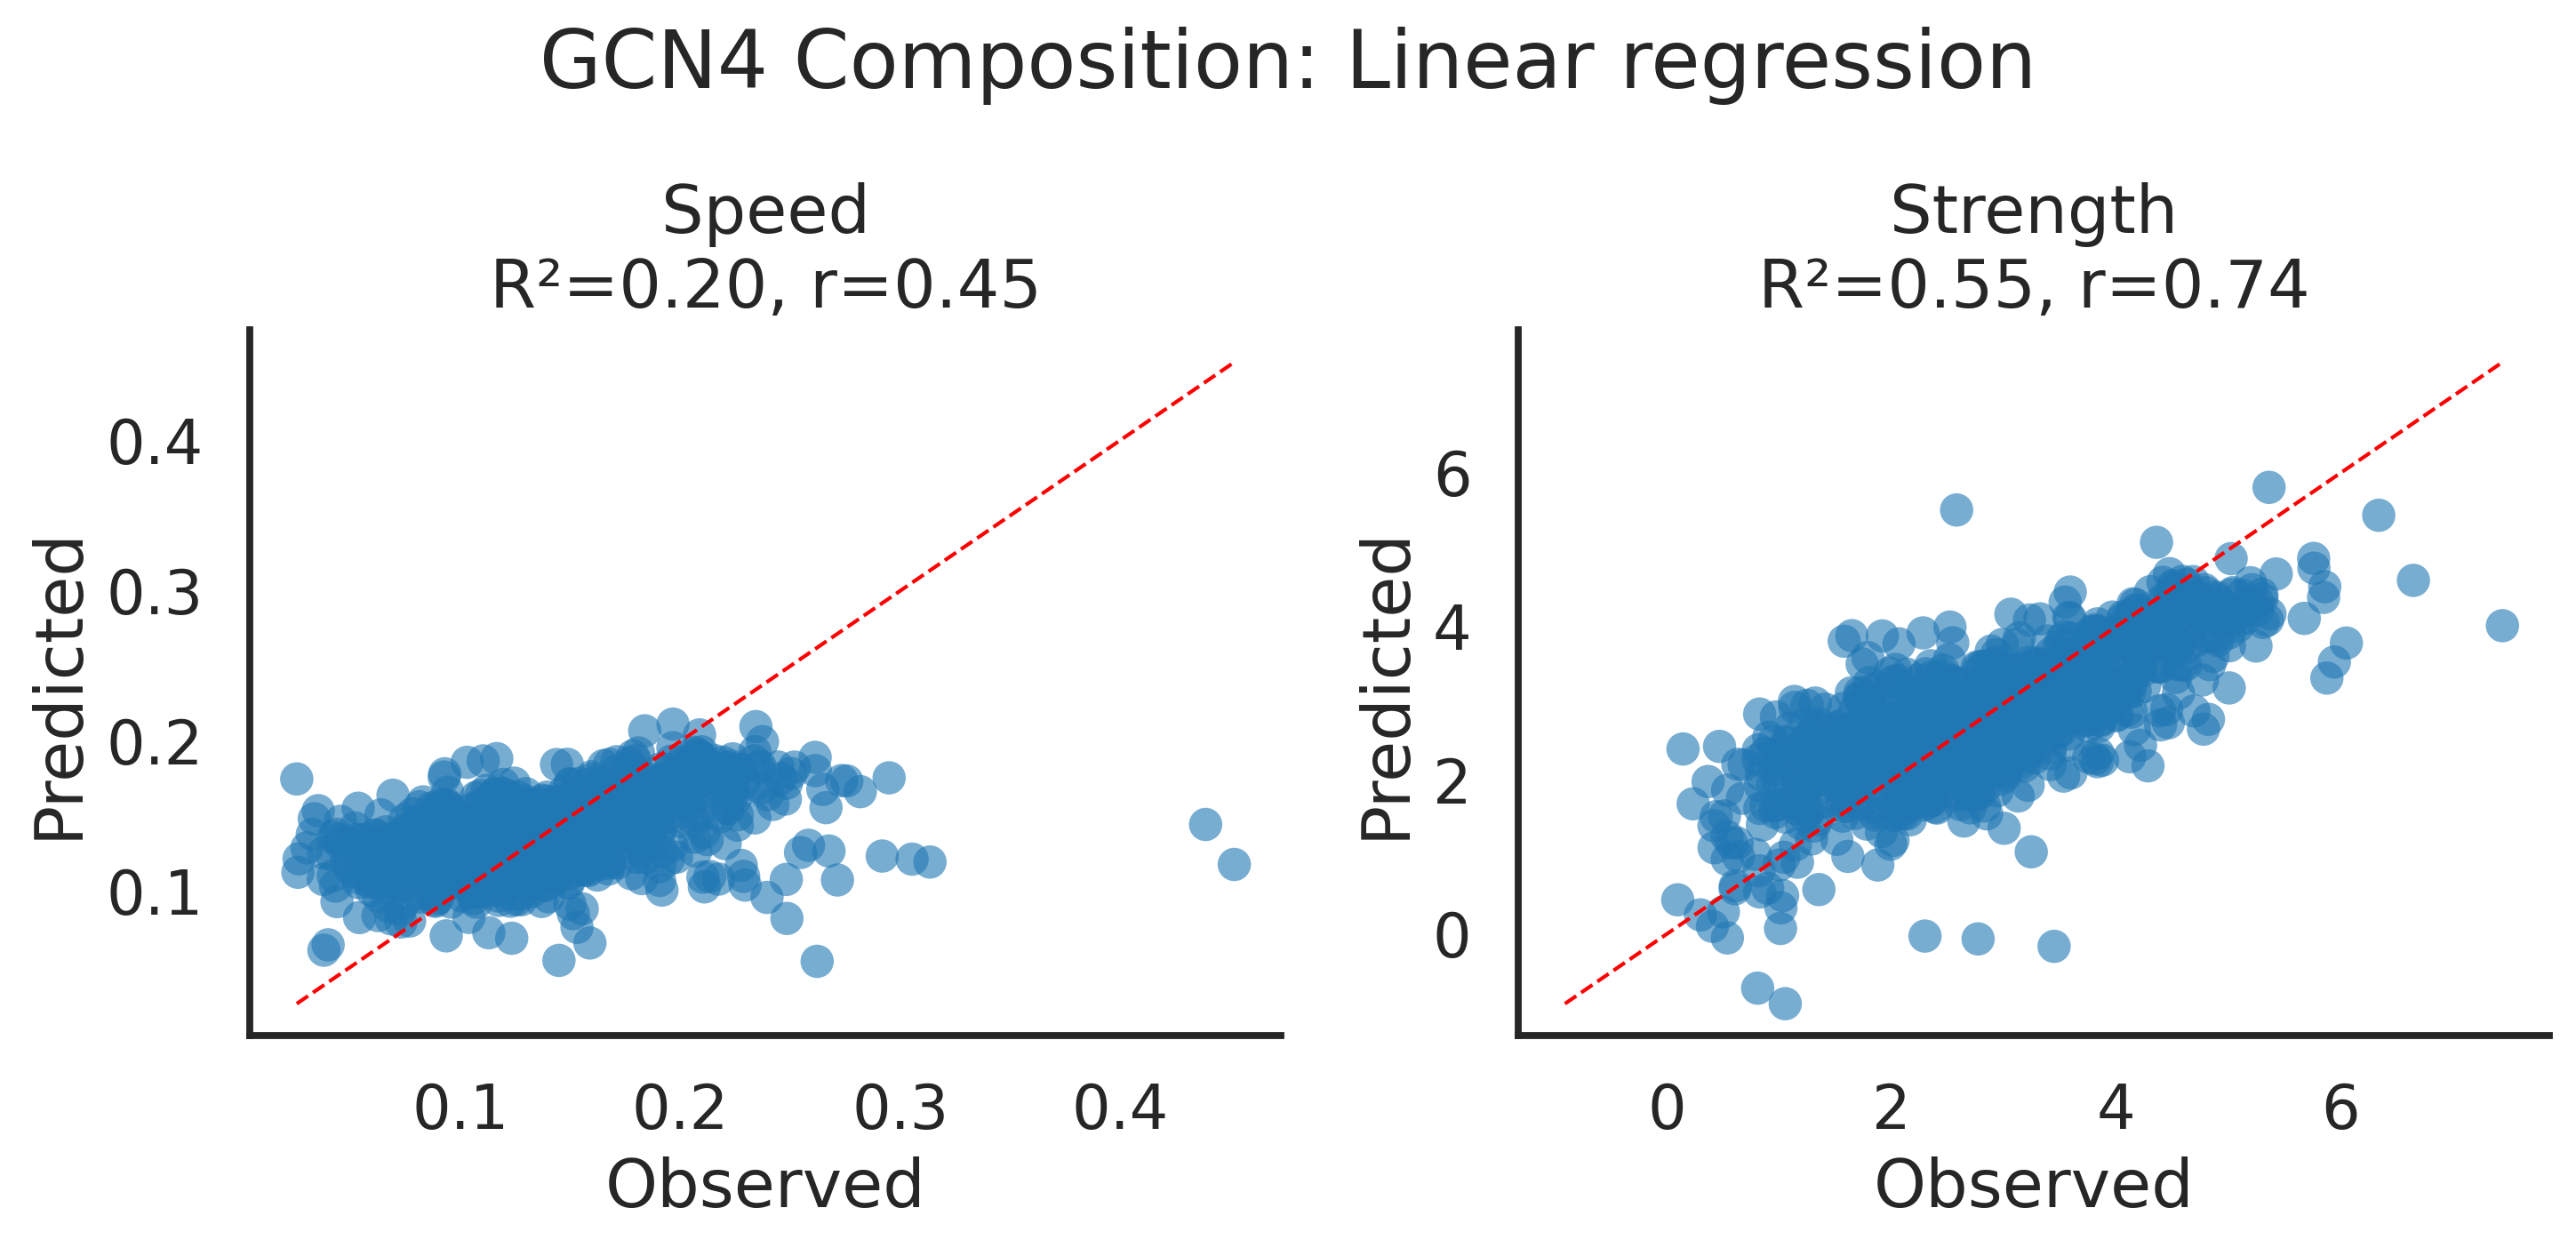

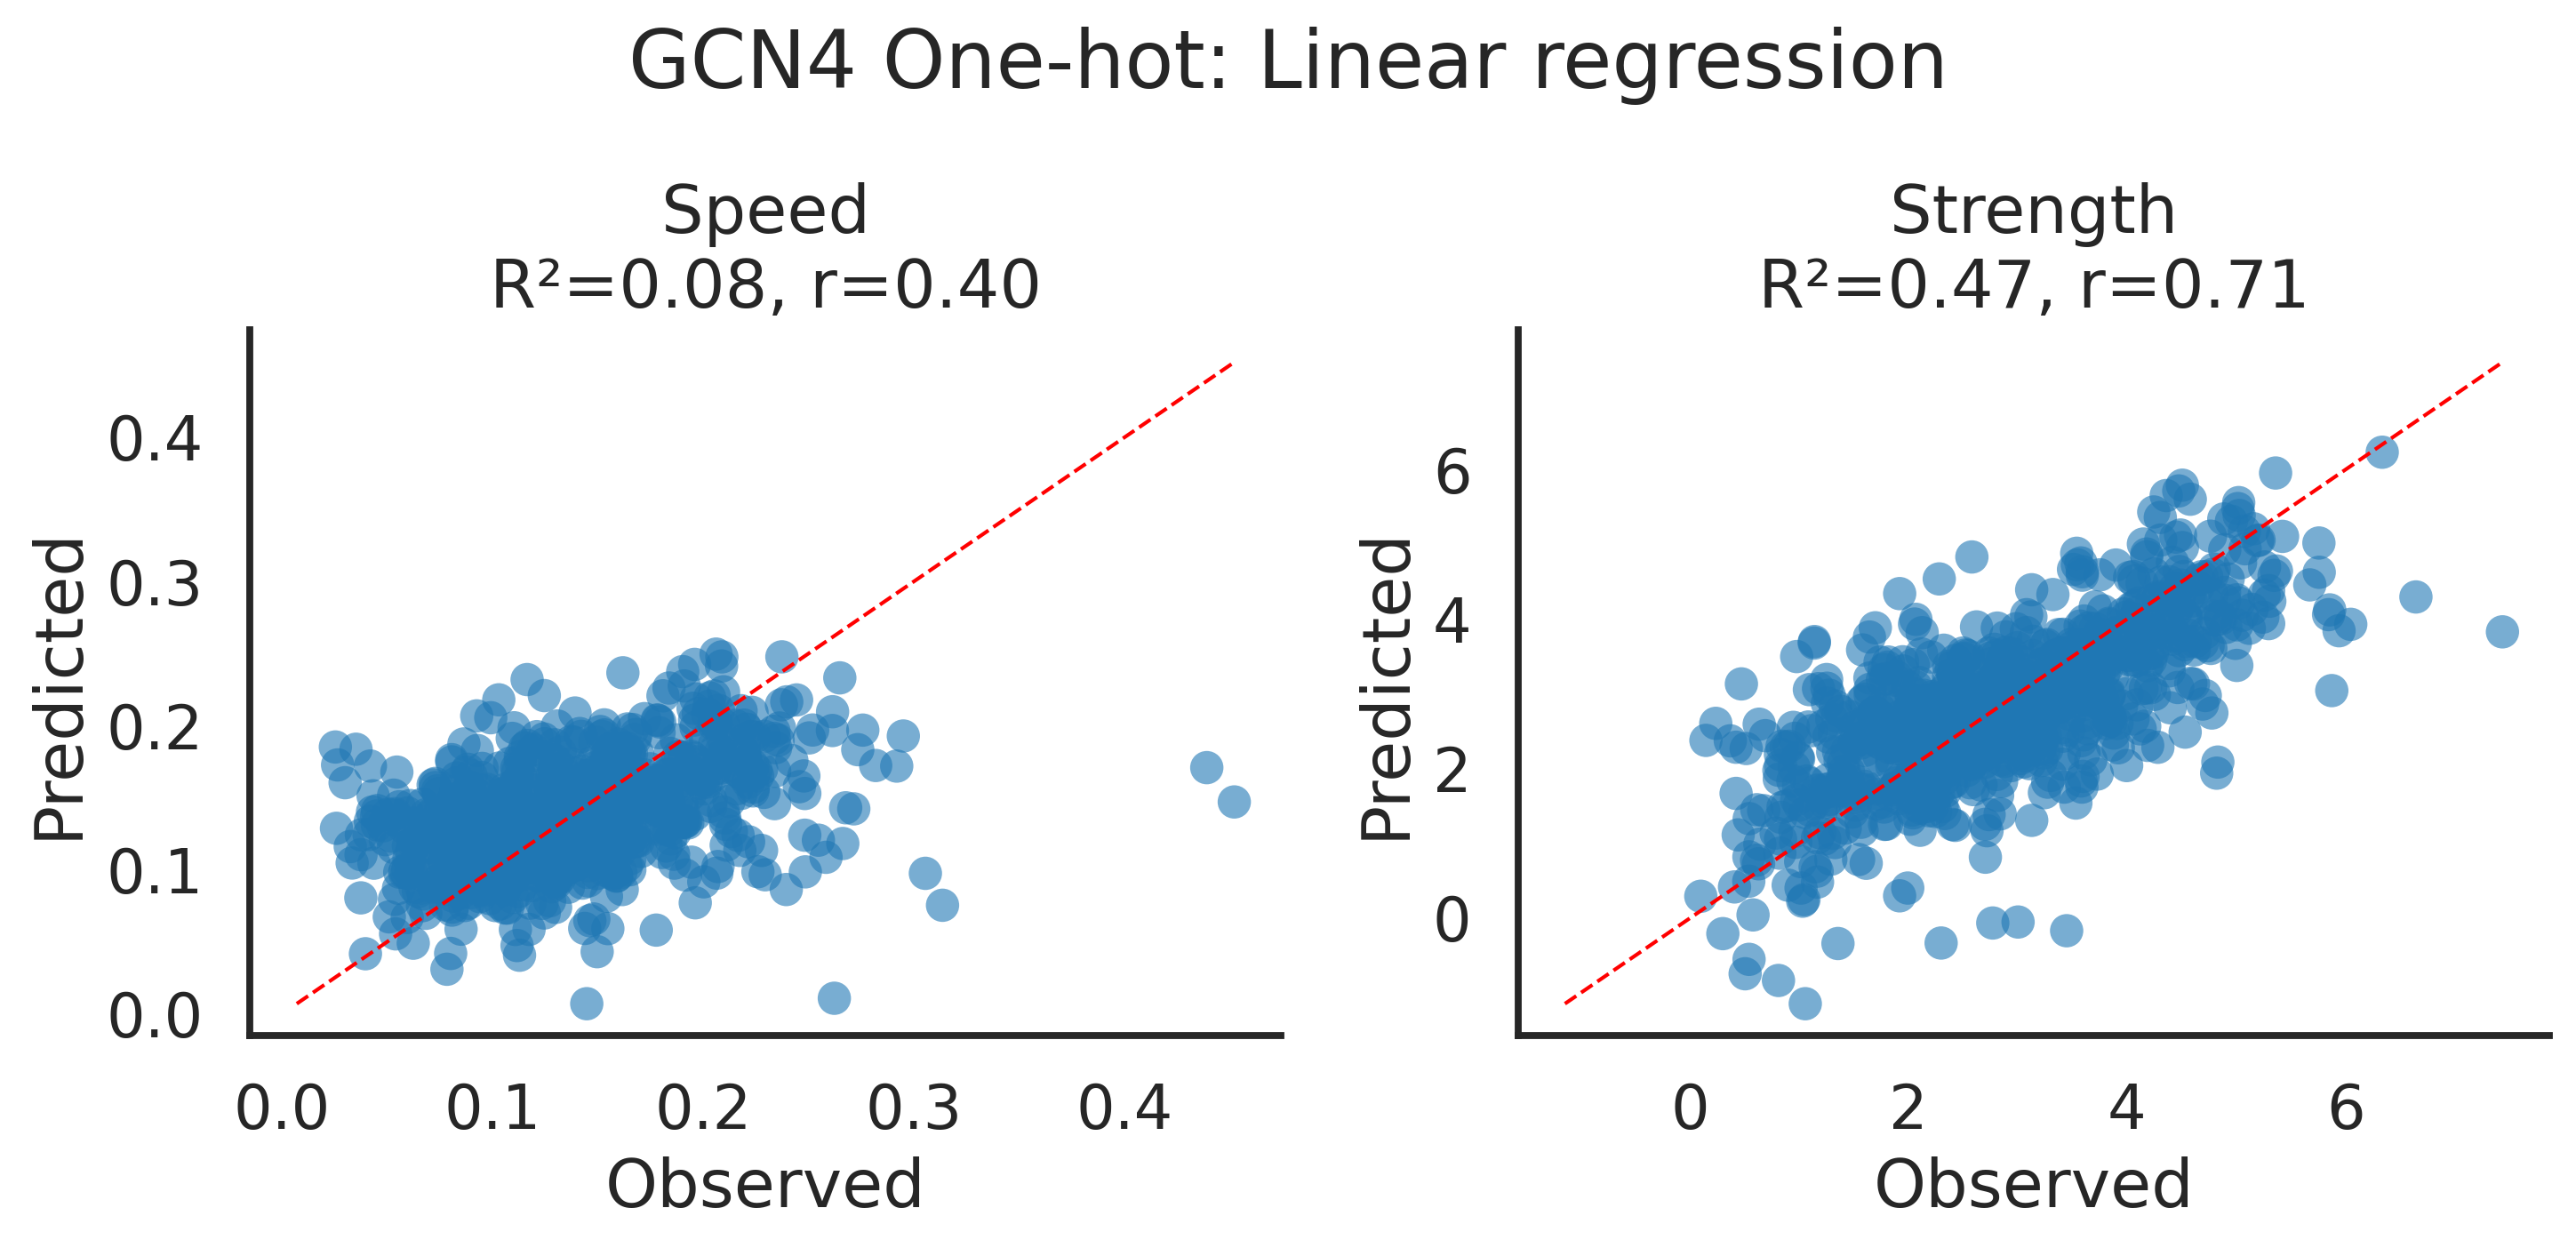

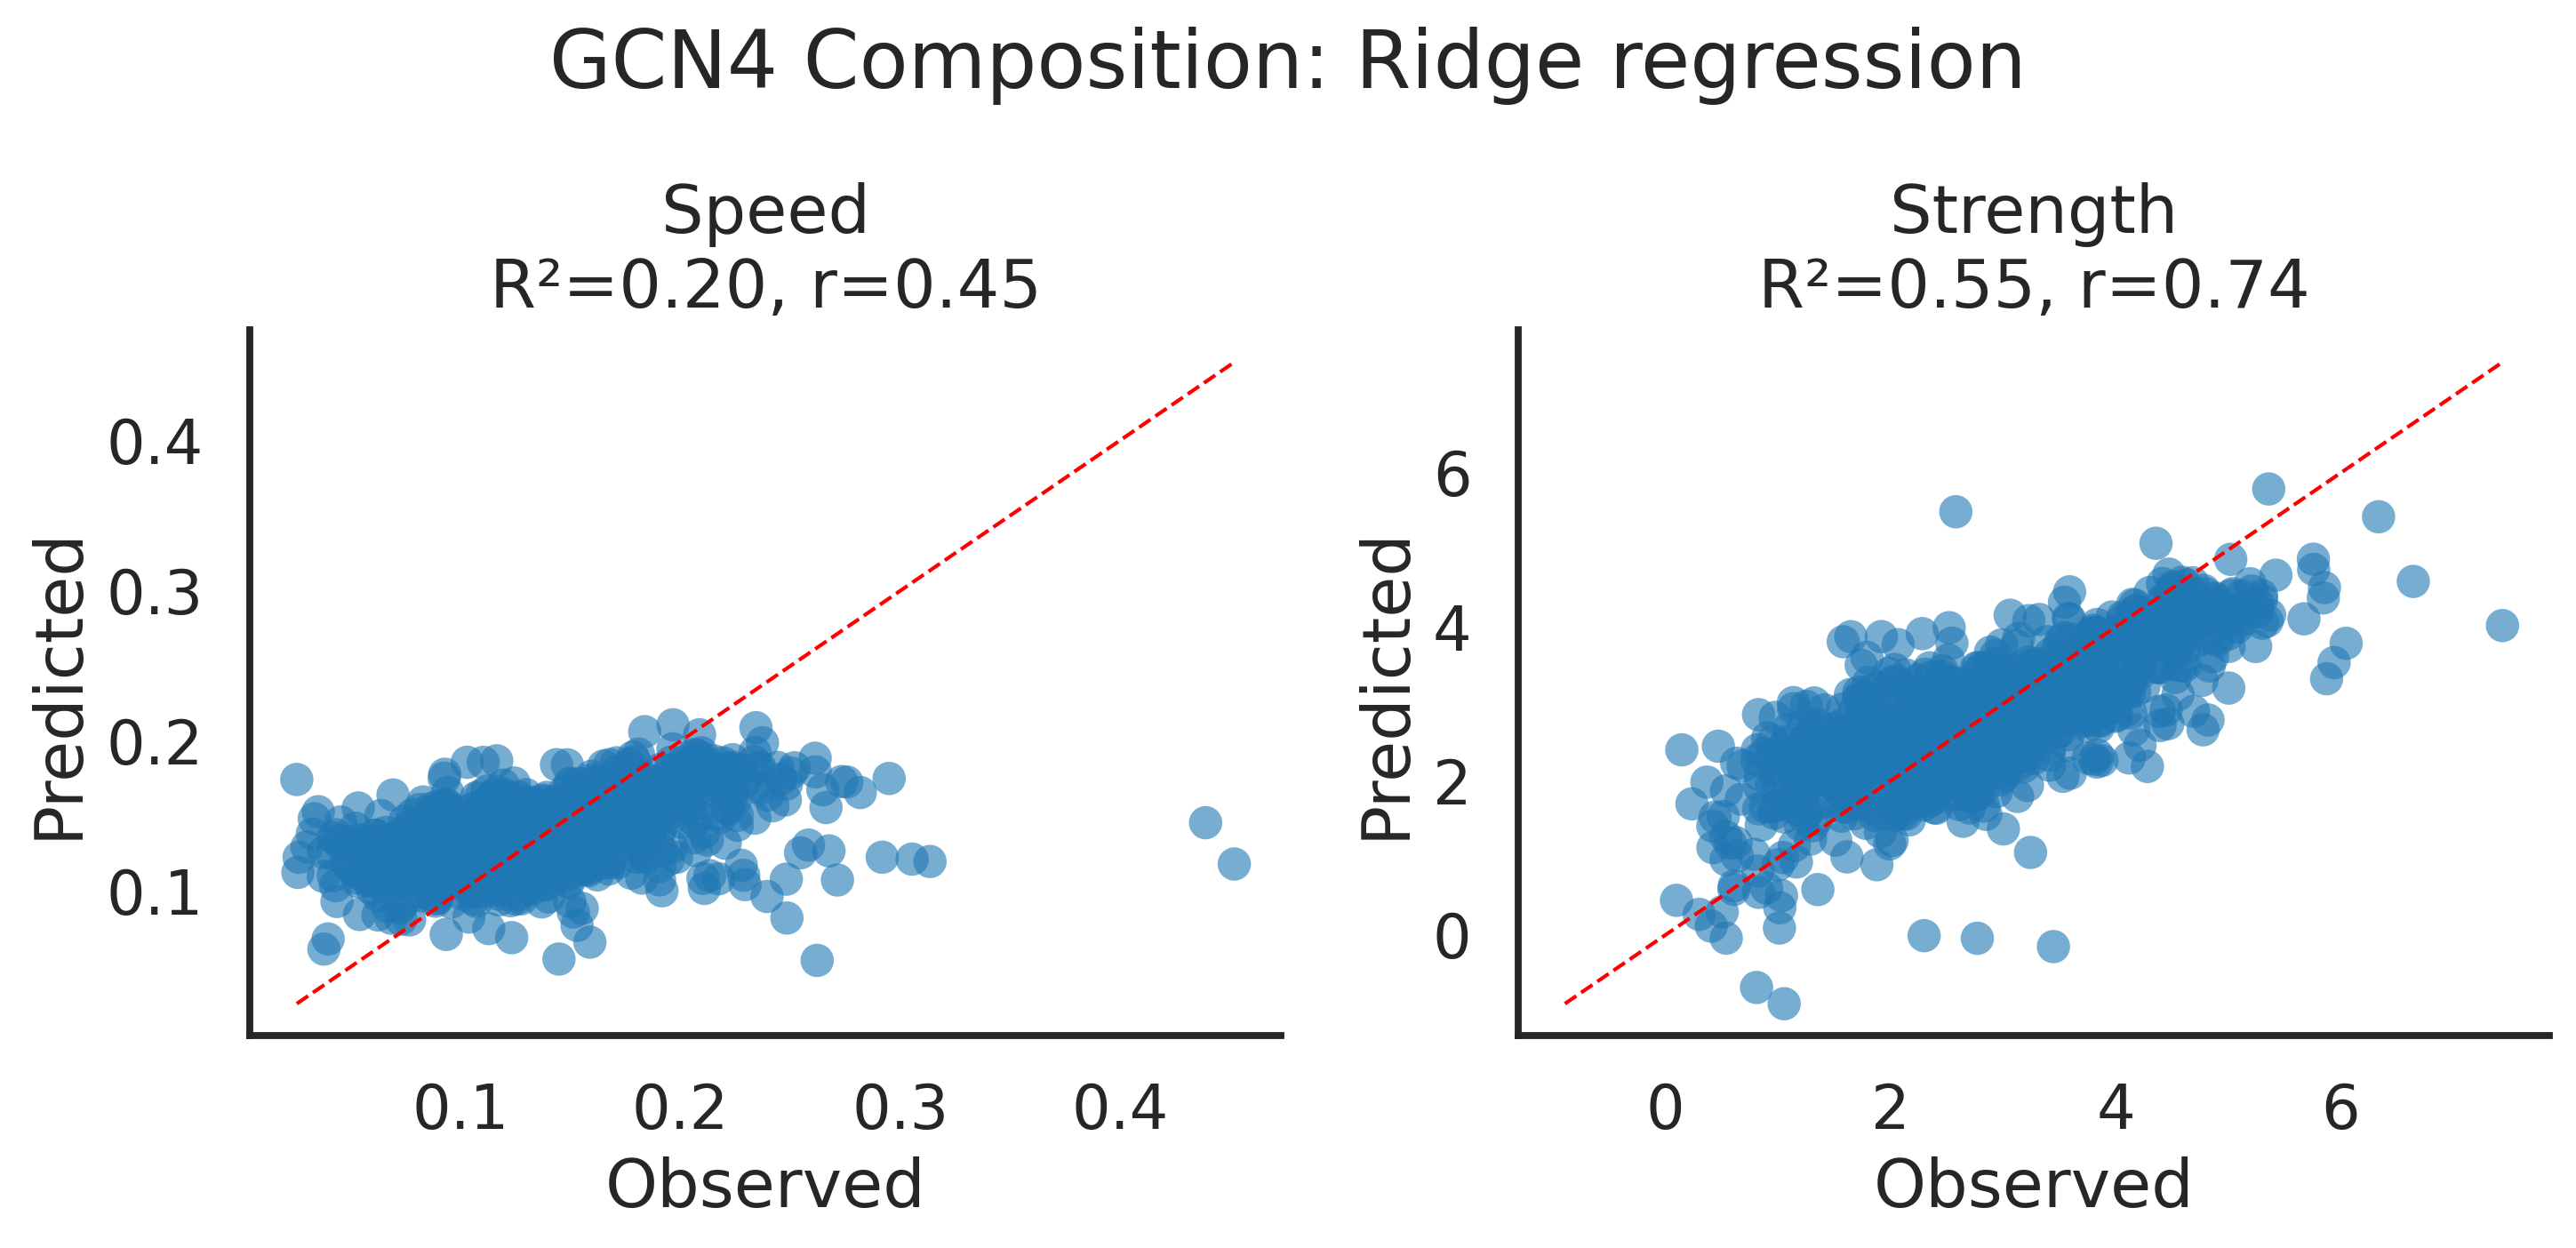

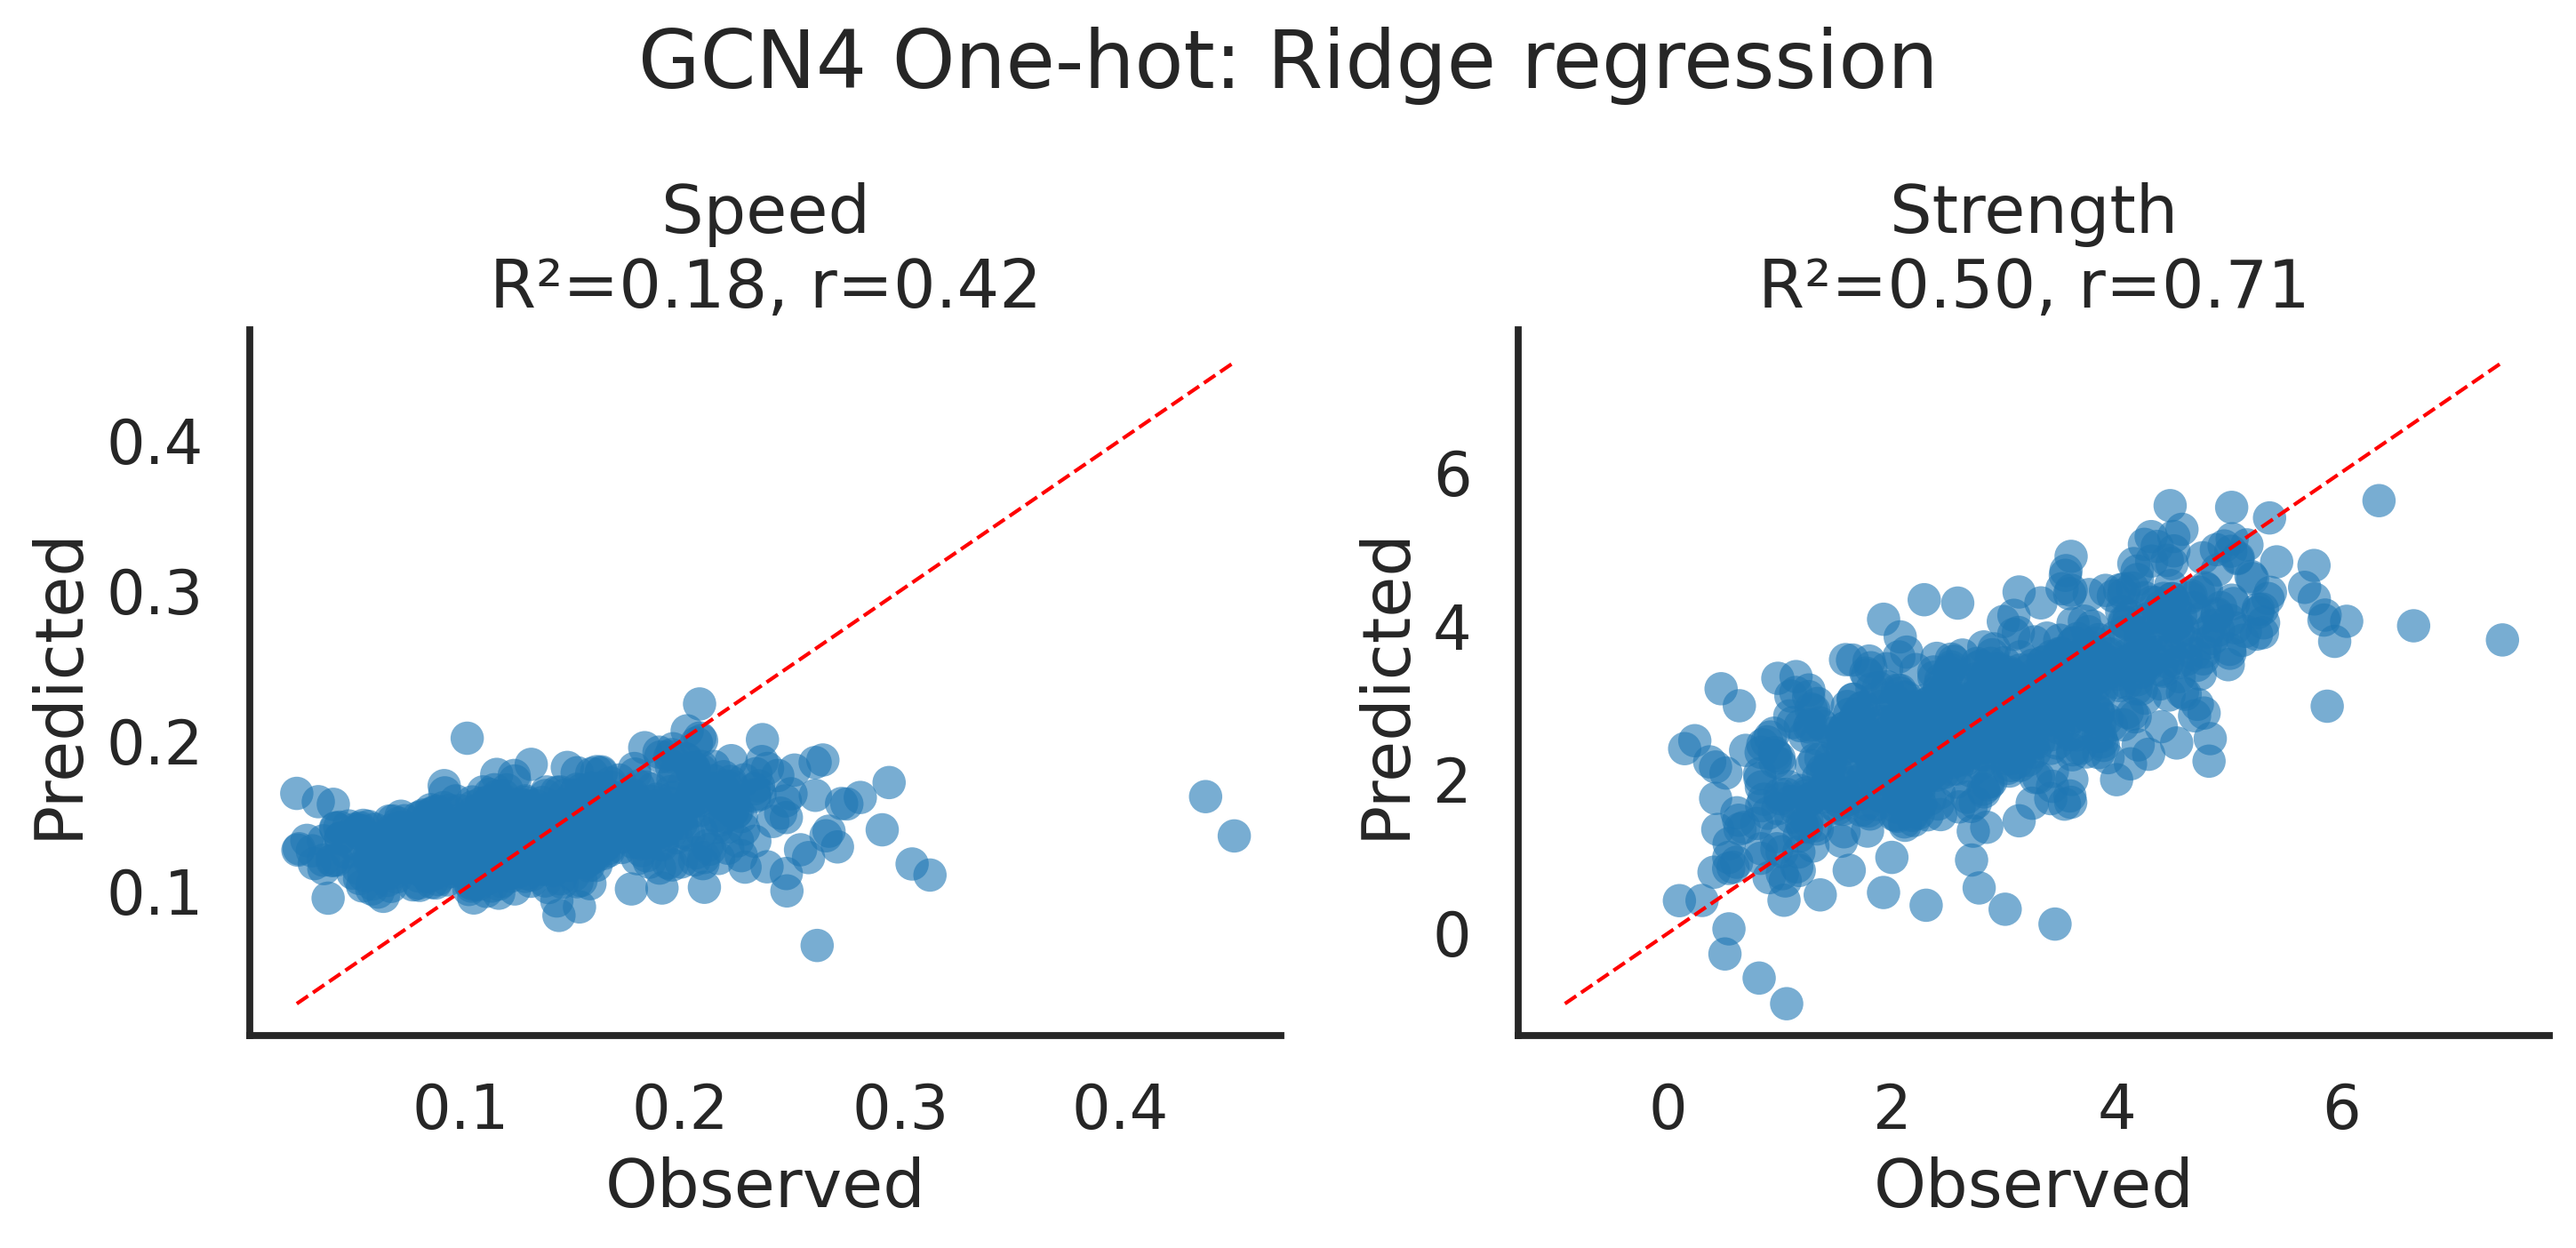

In [7]:
for model_name, artifacts, feature_set, title_prefix, feature_df, top_n in [
    ('Linear regression', composition_linear_artifacts, 'composition', 'Composition', composition_df, 12),
    ('Linear regression', onehot_linear_artifacts, 'one_hot_sequence', 'One-hot', onehot_df, 15),
    ('Ridge regression', composition_ridge_artifacts, 'composition', 'Composition', composition_df, 12),
    ('Ridge regression', onehot_ridge_artifacts, 'one_hot_sequence', 'One-hot', onehot_df, 15),
]:
    plot_prediction_grid(artifacts, feature_set, model_name, title_prefix)

    print(f'Top {feature_set} coefficients for speed ({model_name})')
    display(coefficient_table(
        artifacts[(feature_set, 'speed', model_name)]['estimator'],
        feature_df.columns,
        n=top_n,
    ))

    print(f'Top {feature_set} coefficients for strength ({model_name})')
    display(coefficient_table(
        artifacts[(feature_set, 'strength', model_name)]['estimator'],
        feature_df.columns,
        n=top_n,
    ))


## Do the same features drive speed and strength?

To compare speed and strength on the same scale, this section uses **standardized linear-regression coefficients**. Features in the same-sign quadrants push both traits in the same direction, while opposite-sign features suggest a tradeoff between speed and strength.


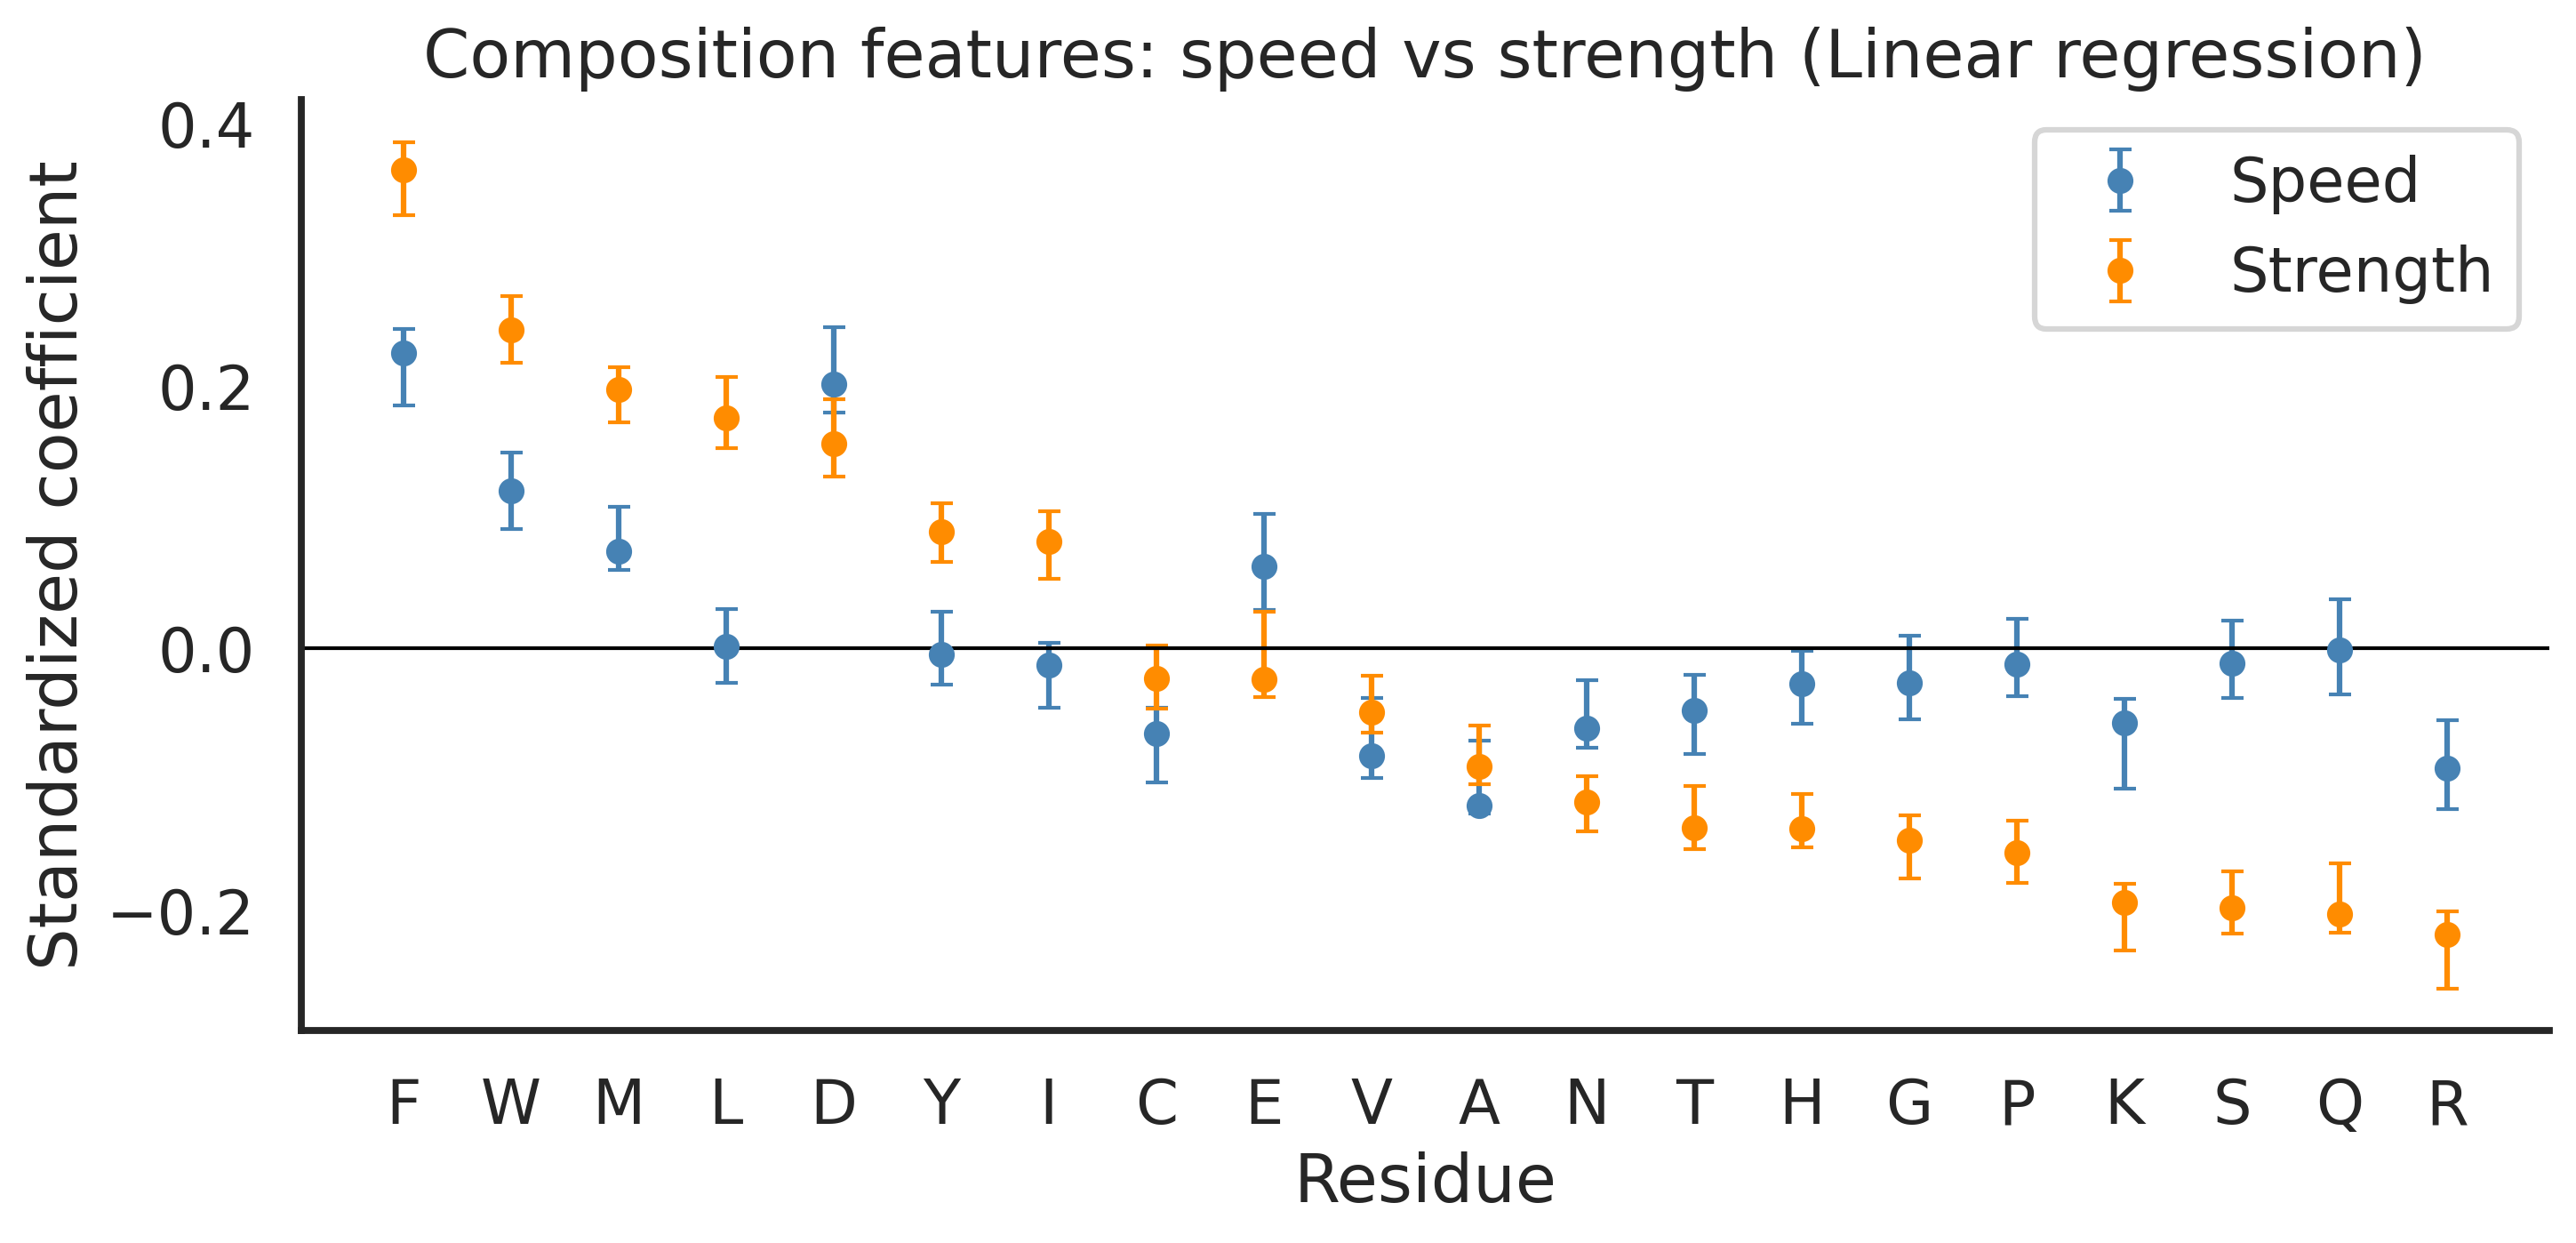

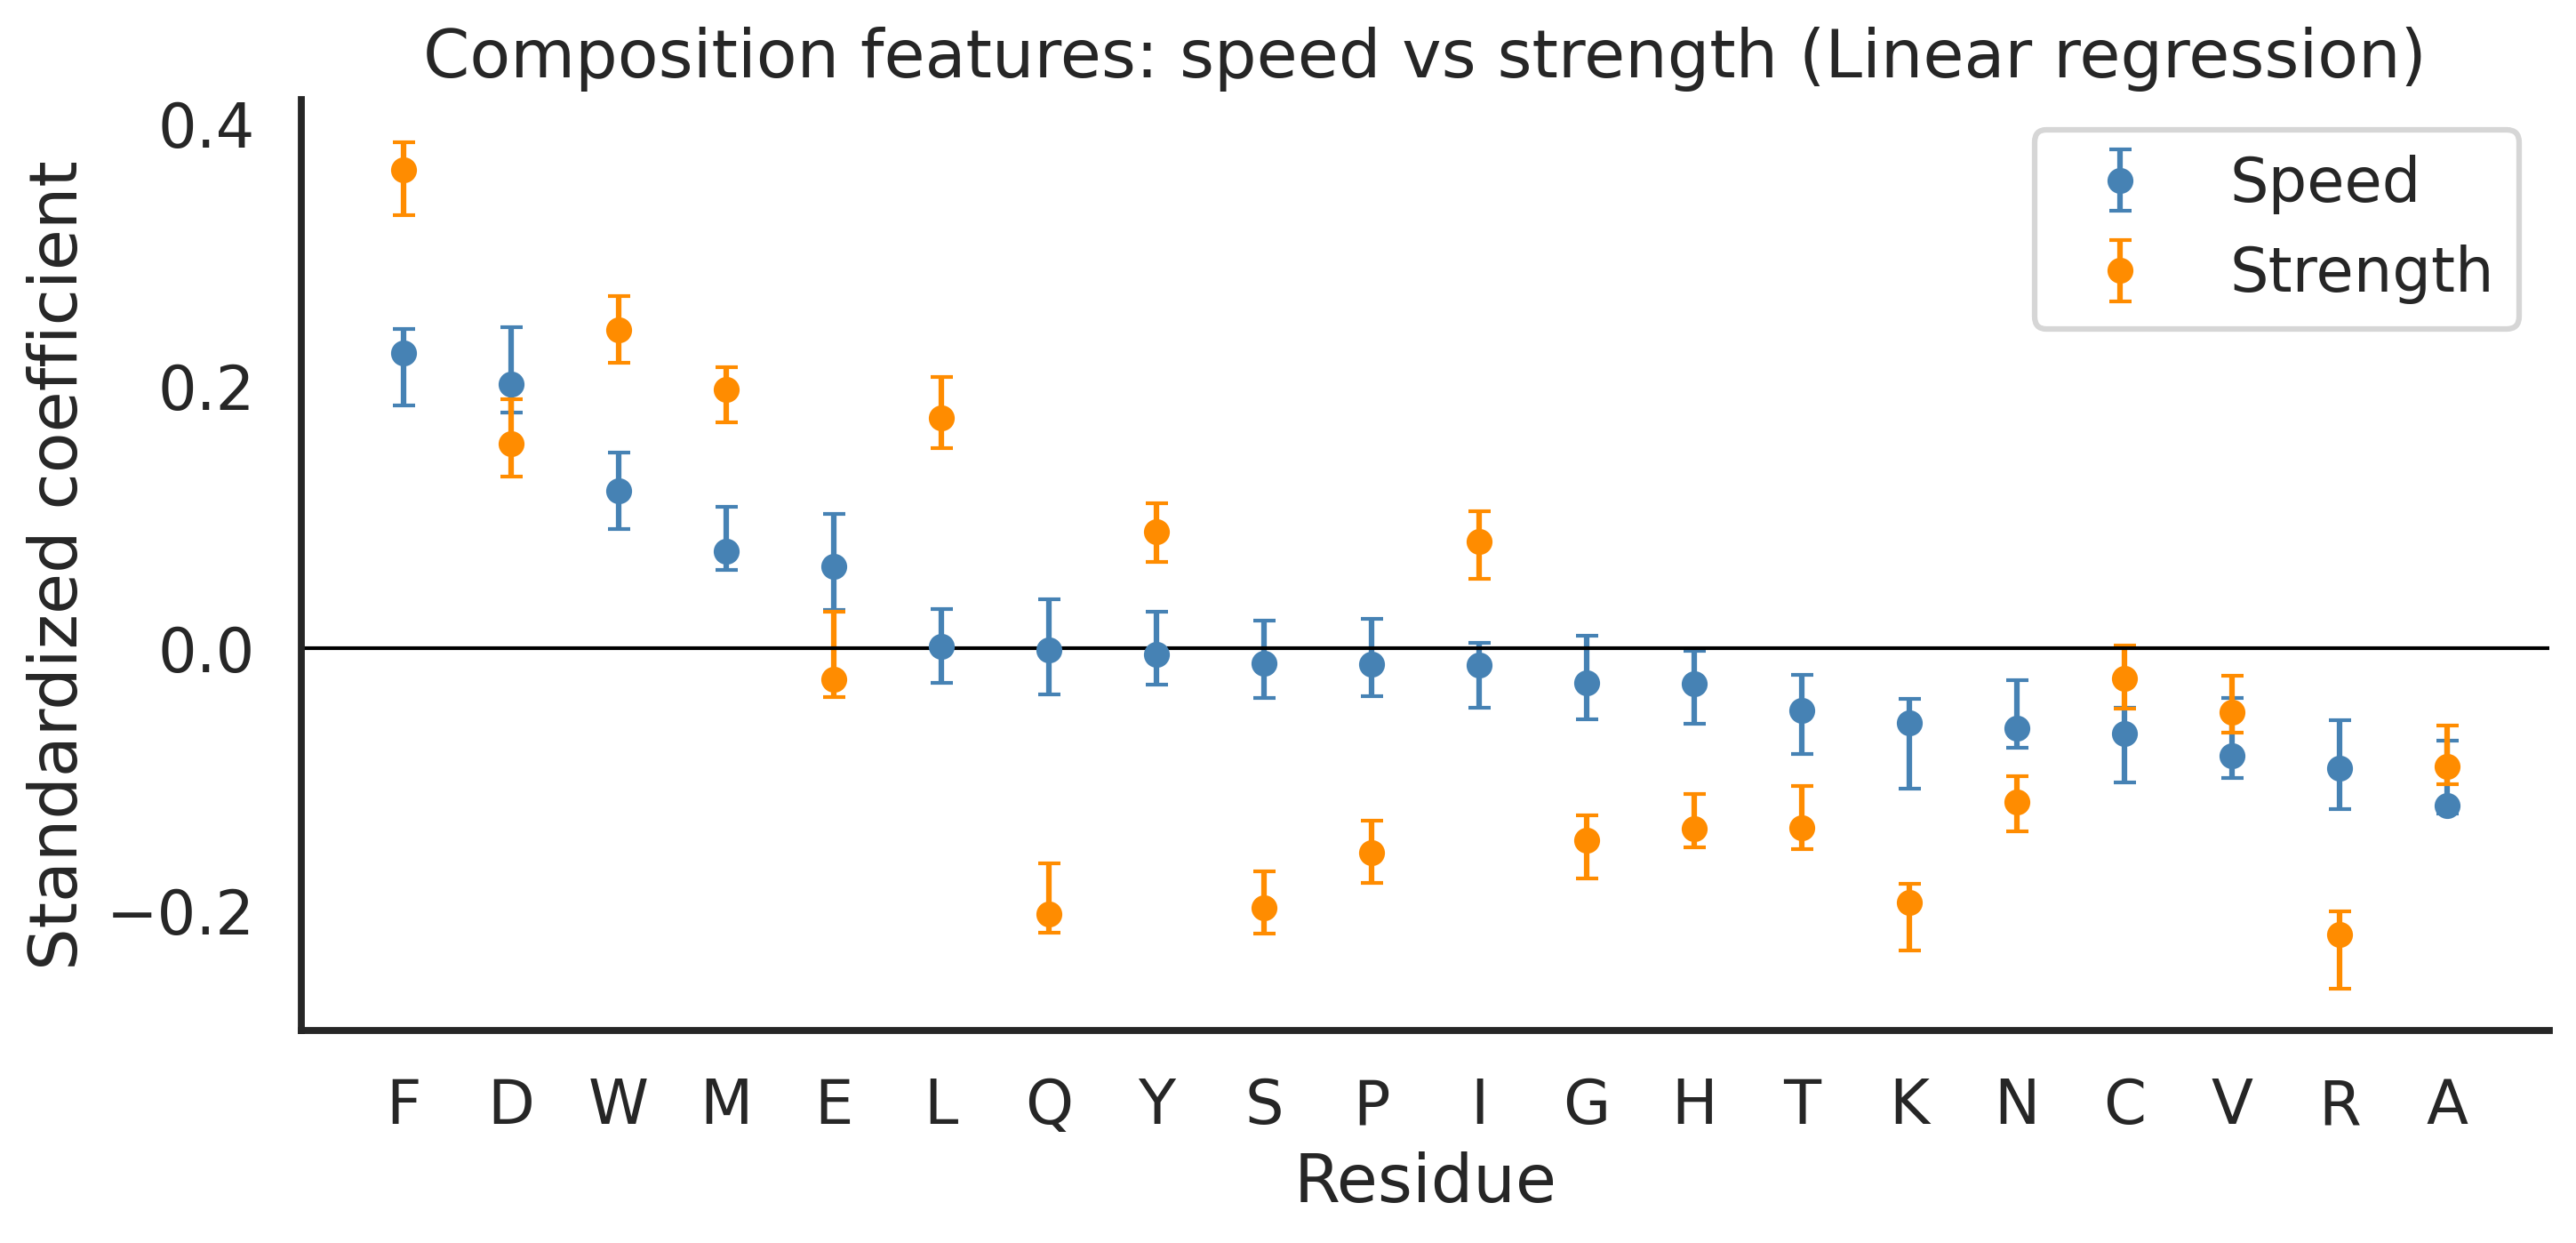

Composition features (Linear regression)


,metric,value
0,Pearson r of standardized coefficients,0.759890
1,Spearman rho of absolute standardized coeffici...,0.099248
2,Fraction of features with the same sign,0.850000


Most shared drivers of speed and strength


,feature,speed_std_coef,strength_std_coef,same_direction,shared_importance
0,F,0.225877,0.365104,True,0.225877
4,D,0.201822,0.156469,True,0.156469
1,W,0.120116,0.243350,True,0.120116
2,R,-0.091033,-0.218094,True,0.091033
13,A,-0.120157,-0.090029,True,0.090029
6,M,0.074175,0.197413,True,0.074175
14,N,-0.060702,-0.116979,True,0.060702
7,K,-0.057082,-0.194103,True,0.057082
17,V,-0.081853,-0.048657,True,0.048657
12,T,-0.047418,-0.136546,True,0.047418


More speed-specific than strength-specific


...

,feature,speed_std_coef,strength_std_coef,same_direction,shared_importance
0,pos40_F,0.077927,0.091445,True,0.077927
12,pos08_F,0.078385,0.073917,True,0.073917
18,pos02_F,0.067926,0.076245,True,0.067926
32,pos34_W,0.065328,0.069241,True,0.065328
5,pos12_F,0.063619,0.083192,True,0.063619
46,pos35_W,0.061880,0.063817,True,0.061880
64,pos08_R,-0.057663,-0.058322,True,0.057663
17,pos24_F,0.057063,0.076732,True,0.057063
50,pos17_F,0.055628,0.062414,True,0.055628
21,pos07_F,0.054256,0.074533,True,0.054256


More speed-specific than strength-specific


,feature,speed_std_coef,strength_std_coef,importance_gap
44,pos07_P,0.064032,0.001468,0.062564
55,pos39_V,-0.059528,0.006704,0.052824
52,pos25_N,-0.061280,-0.013545,0.047735
73,pos39_A,-0.056310,-0.014813,0.041497
114,pos07_L,-0.048771,0.007568,0.041203
71,pos23_D,0.057034,0.016130,0.040904
115,pos21_V,0.048638,-0.009401,0.039237
174,pos09_E,0.042456,-0.004137,0.038319
70,pos04_D,0.057832,0.020274,0.037559
199,pos01_Q,0.040621,-0.003244,0.037377


More strength-specific than speed-specific


,feature,speed_std_coef,strength_std_coef,importance_gap
25,pos29_L,-0.005014,0.072103,-0.067088
16,pos39_F,0.011602,0.077238,-0.065635
14,pos32_F,0.012635,0.077798,-0.065163
11,pos23_F,0.014529,0.078628,-0.064099
37,pos38_L,0.006679,0.067858,-0.061178
26,pos15_W,0.011161,0.071861,-0.060700
33,pos20_W,0.010039,0.069226,-0.059187
51,pos27_L,0.004807,0.061780,-0.056973
13,pos22_L,0.021565,0.078350,-0.056785
9,pos29_F,0.023101,0.079544,-0.056443


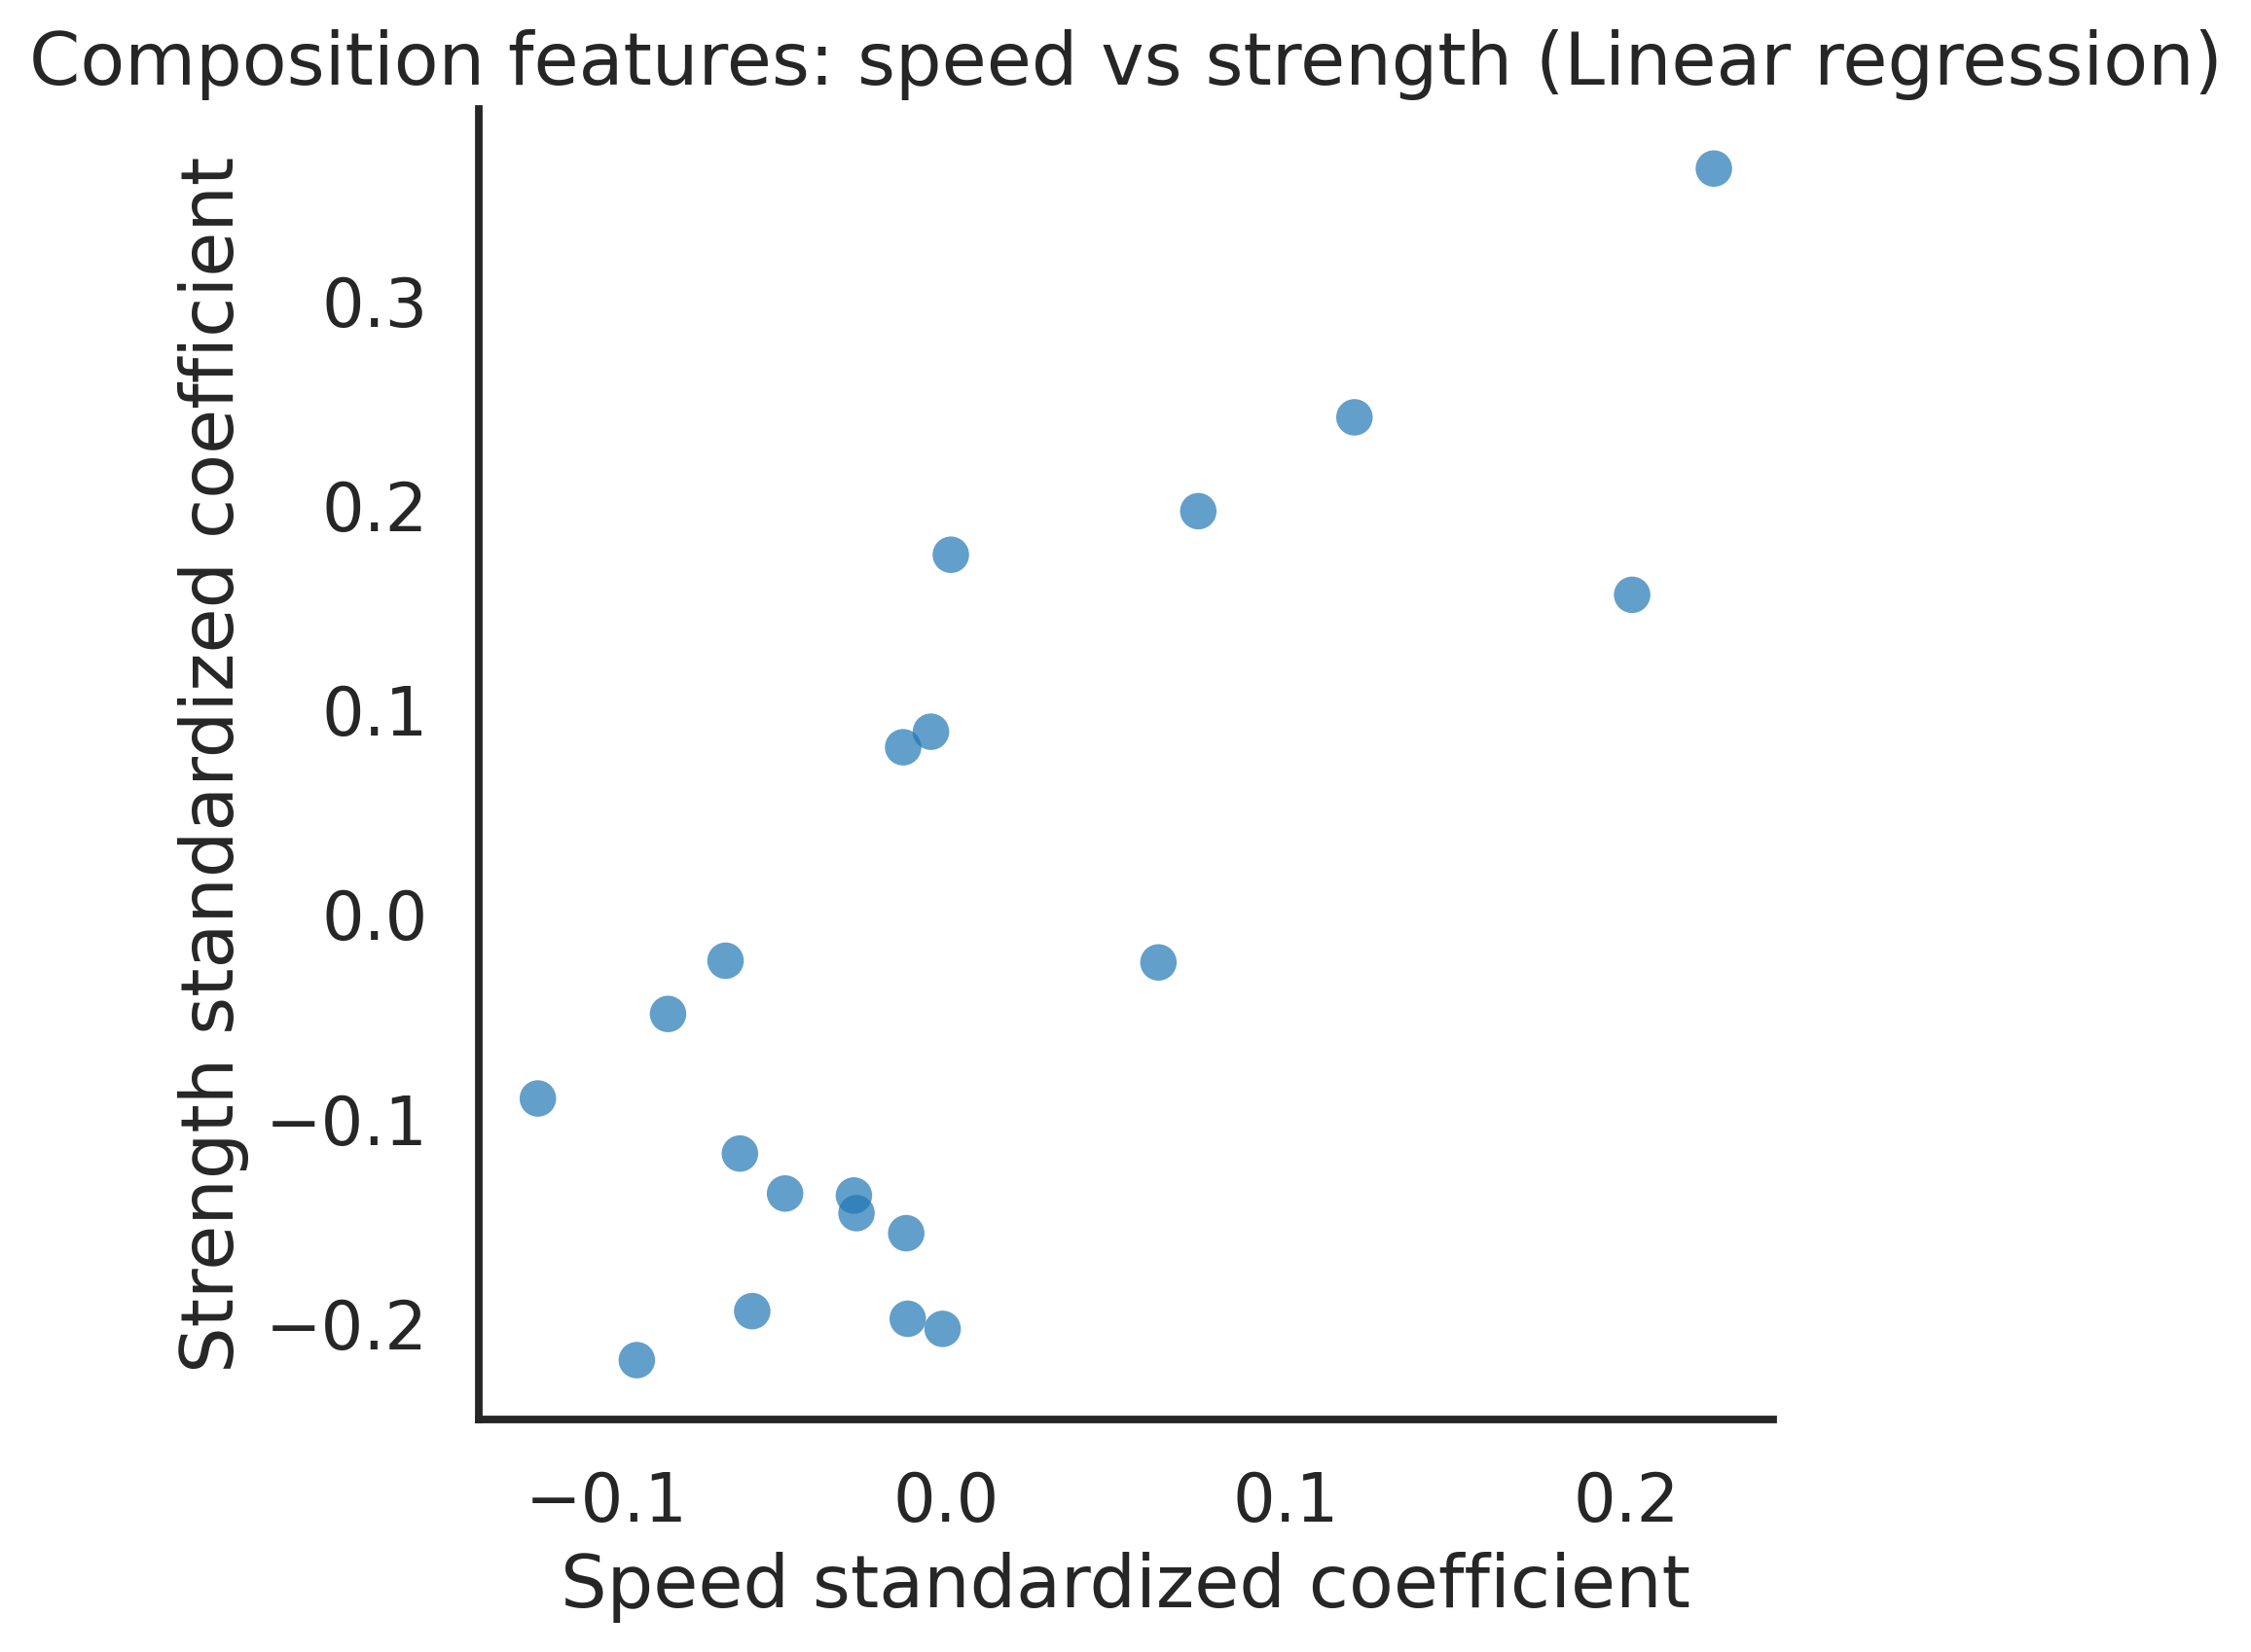

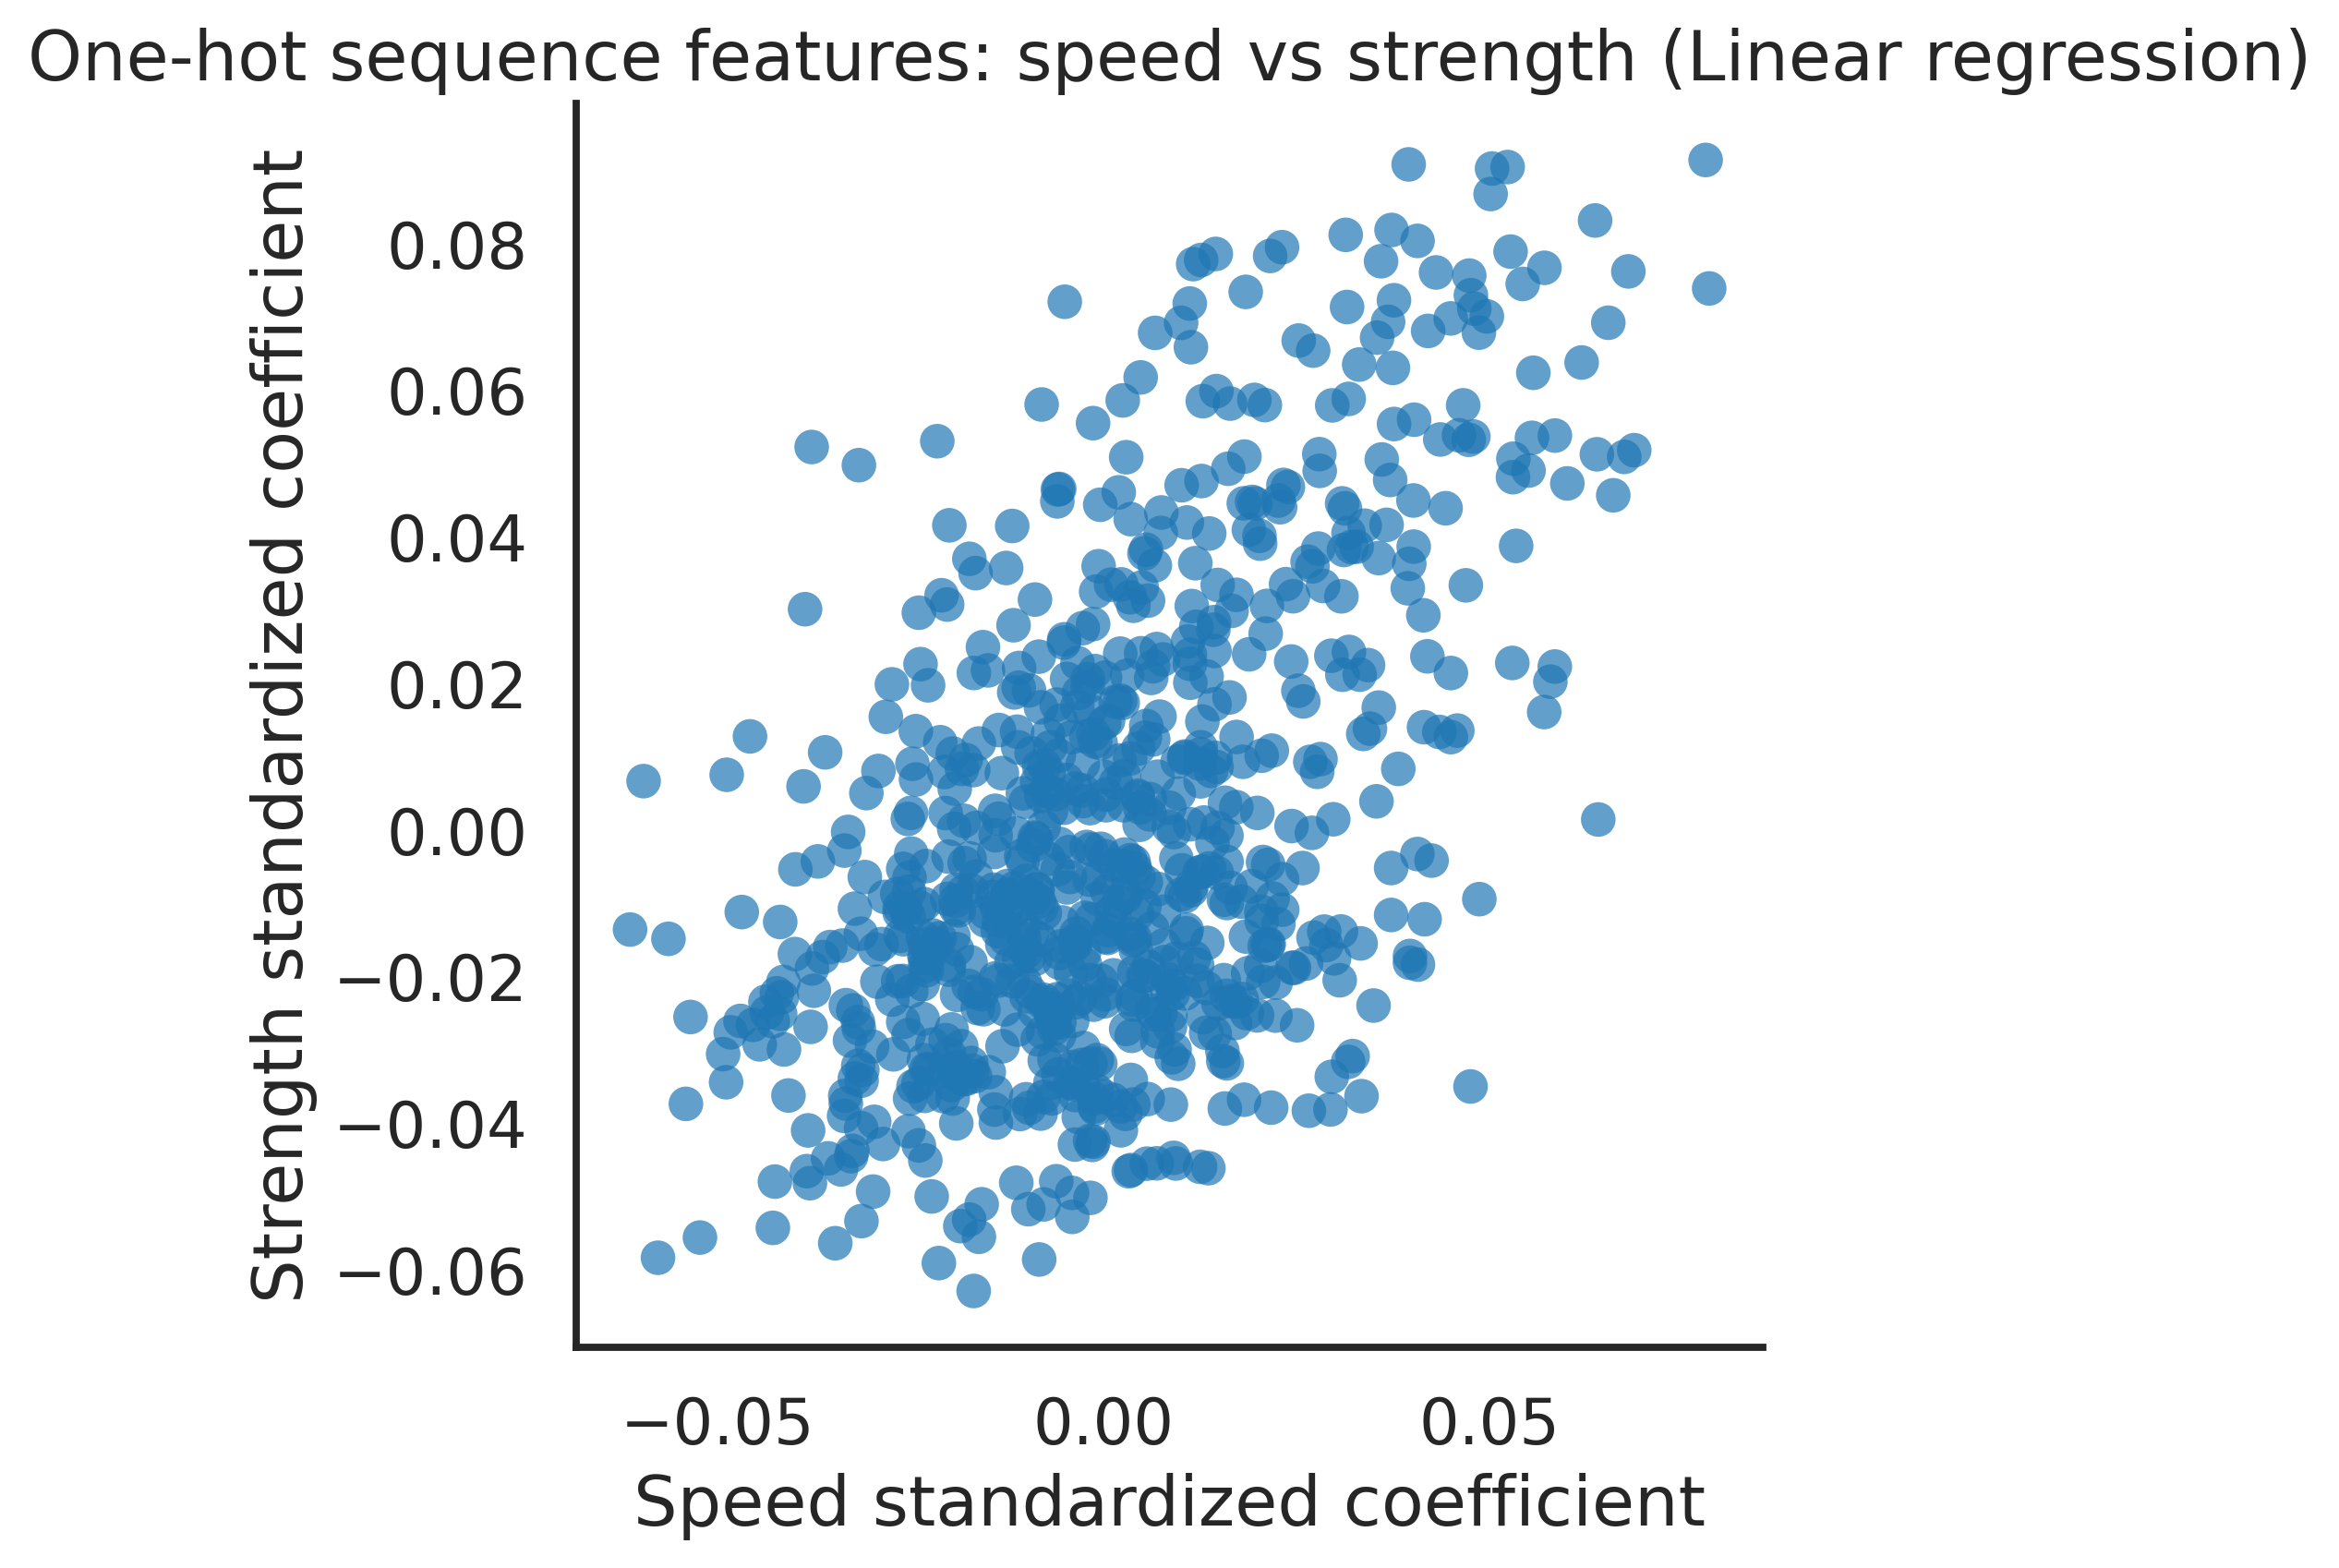

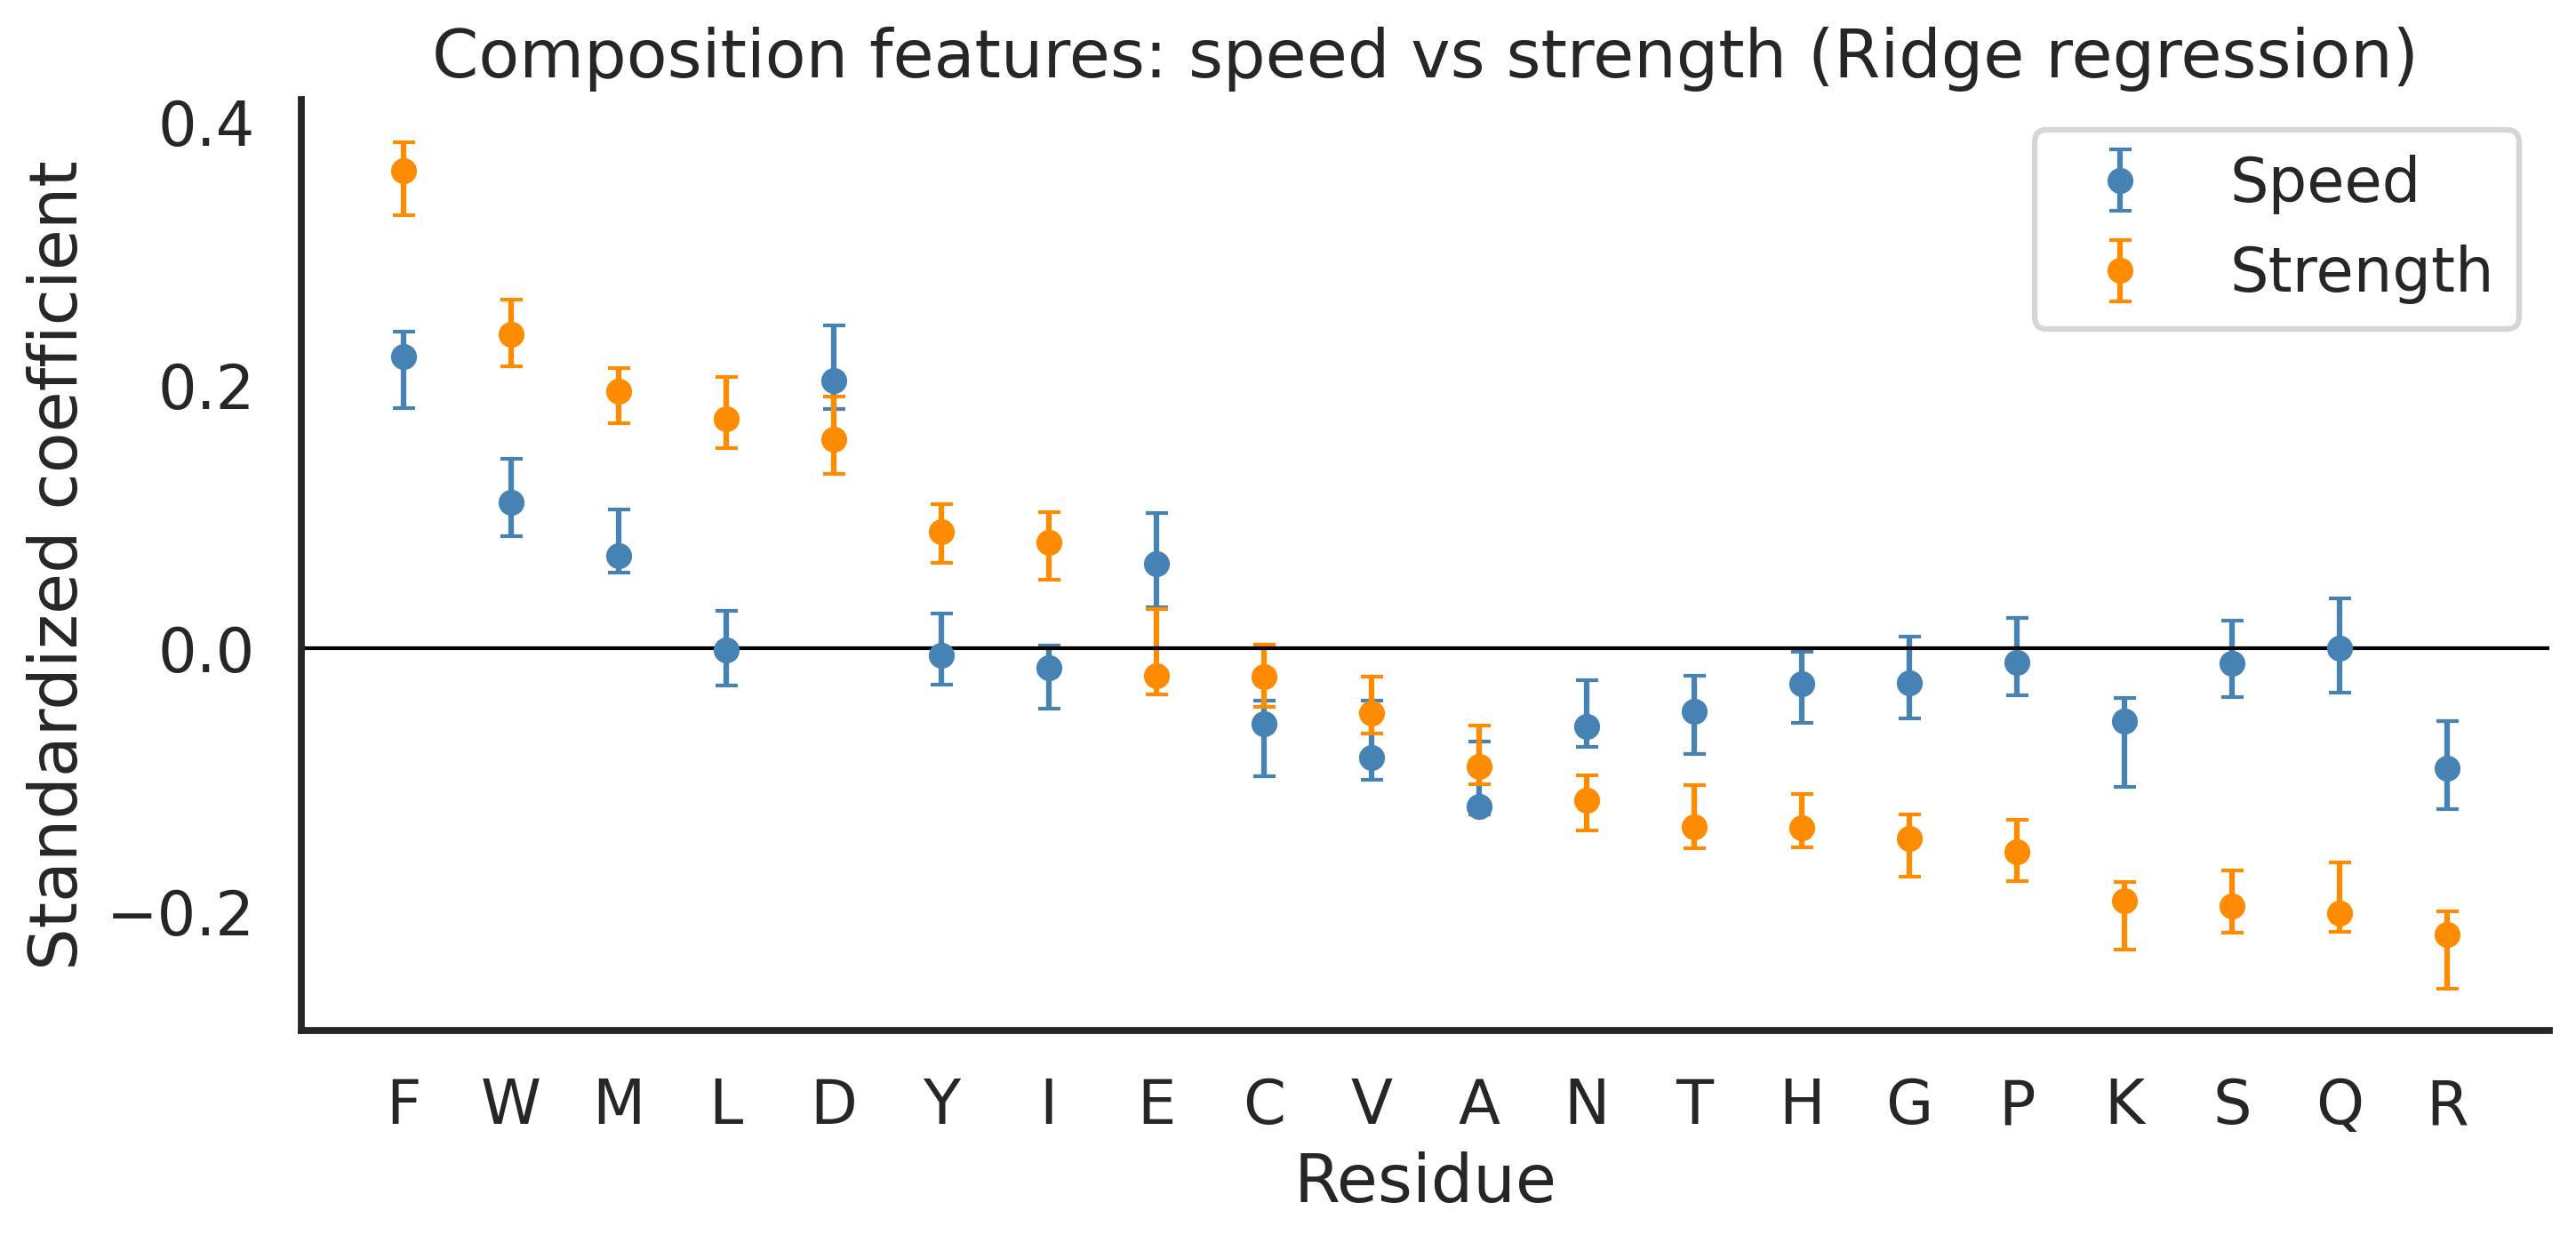

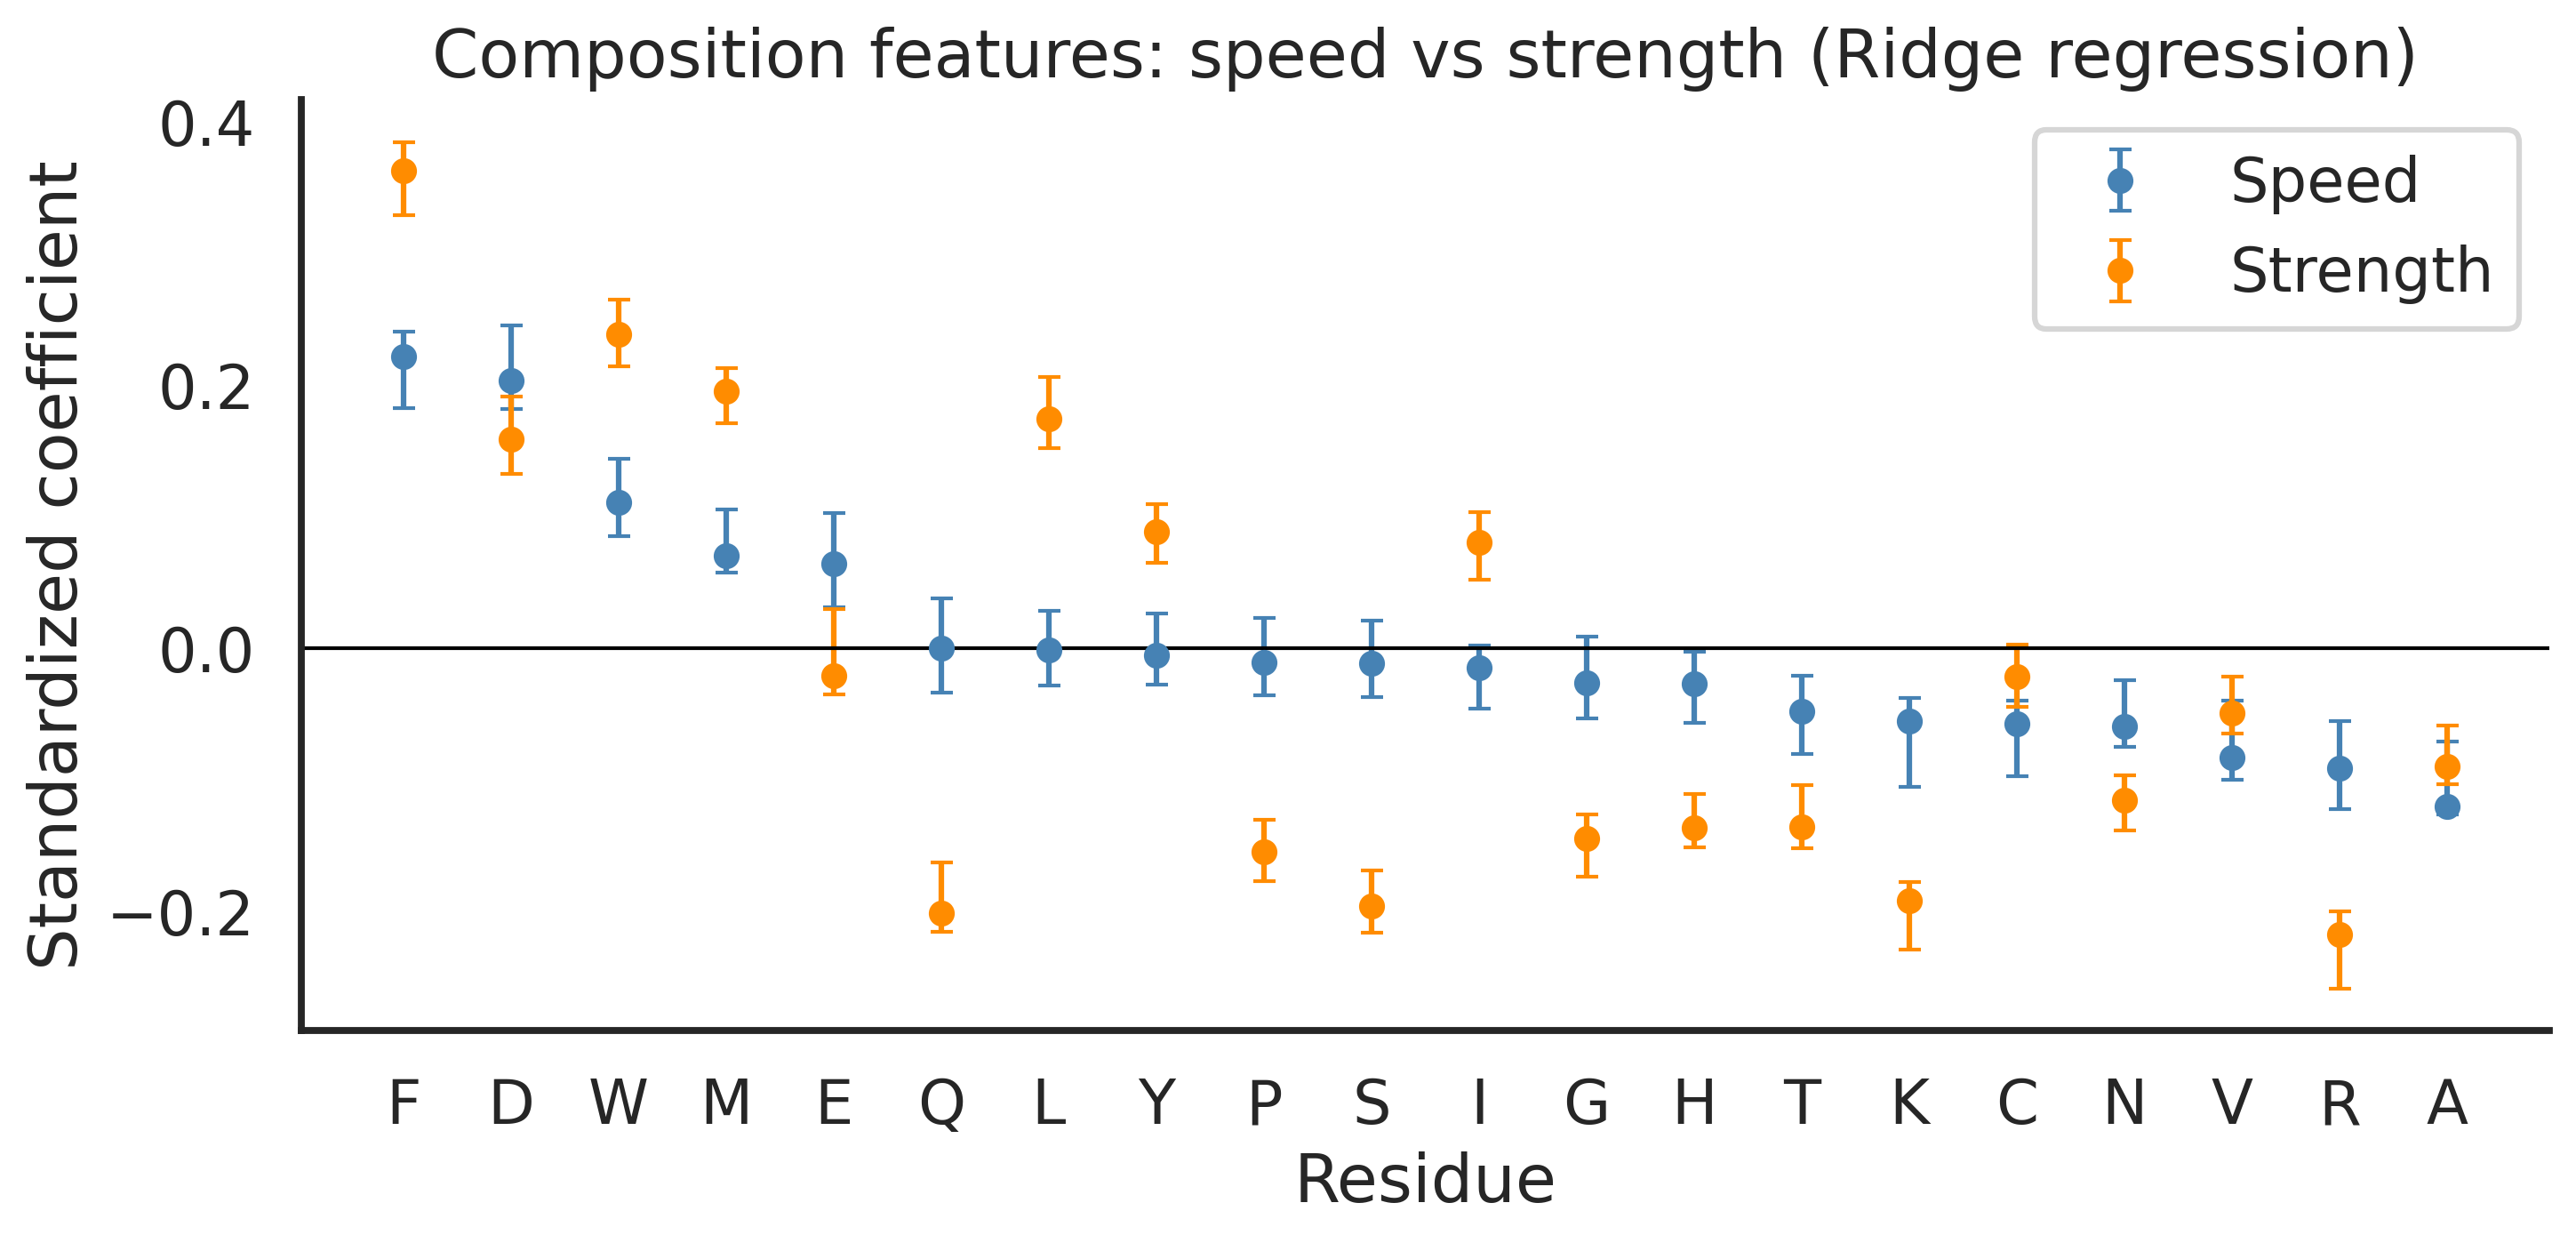

Composition features (Ridge regression)


,metric,value
0,Pearson r of standardized coefficients,0.753022
1,Spearman rho of absolute standardized coeffici...,0.114286
2,Fraction of features with the same sign,0.750000


Most shared drivers of speed and strength


,feature,speed_std_coef,strength_std_coef,same_direction,shared_importance
0,F,0.221822,0.363025,True,0.221822
3,D,0.203619,0.158927,True,0.158927
1,W,0.111326,0.238606,True,0.111326
2,R,-0.091303,-0.217479,True,0.091303
13,A,-0.120337,-0.089578,True,0.089578
6,M,0.070737,0.195513,True,0.070737
14,N,-0.059435,-0.115472,True,0.059435
7,K,-0.054965,-0.191883,True,0.054965
16,V,-0.083023,-0.049429,True,0.049429
12,T,-0.047551,-0.135594,True,0.047551


More speed-specific than strength-specific


,feature,speed_std_coef,strength_std_coef,importance_gap
3,D,0.203619,0.158927,0.044693
18,E,0.064599,-0.020950,0.043649
19,C,-0.057426,-0.021503,0.035923
16,V,-0.083023,-0.049429,0.033595
13,A,-0.120337,-0.089578,0.030760
14,N,-0.059435,-0.115472,-0.056037
17,I,-0.014679,0.080743,-0.066064
15,Y,-0.005177,0.088455,-0.083278
12,T,-0.047551,-0.135594,-0.088043
11,H,-0.027035,-0.136497,-0.109461


More strength-specific than speed-specific


,feature,speed_std_coef,strength_std_coef,importance_gap
4,Q,0.000273,-0.201133,-0.200860
5,S,-0.011113,-0.196203,-0.185090
8,L,-0.001235,0.174857,-0.173622
9,P,-0.010942,-0.154513,-0.143571
0,F,0.221822,0.363025,-0.141203
7,K,-0.054965,-0.191883,-0.136918
1,W,0.111326,0.238606,-0.127280
2,R,-0.091303,-0.217479,-0.126176
6,M,0.070737,0.195513,-0.124776
10,G,-0.025950,-0.144358,-0.118408


In [ ]:
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------
# Standardized coefficient table for a fitted model
# ---------------------------------------------------------
def standardized_coefficient_table(model, X, y):
    coef = pd.Series(np.asarray(model.coef_).reshape(-1), index=X.columns)
    feature_std = X.std(ddof=0).replace(0, np.nan)
    y_std = np.std(y)
    standardized = (coef * feature_std / y_std).fillna(0.0)

    return pd.DataFrame({
        'feature': X.columns,
        'coef': coef.reindex(X.columns).to_numpy(),
        'std_coef': standardized.reindex(X.columns).to_numpy(),
    }).assign(abs_std_coef=lambda df: df['std_coef'].abs())


# ---------------------------------------------------------
# Bootstrap standardized coefficients for linear models
# ---------------------------------------------------------
def bootstrap_standardized_coefficients(X, y, model_builder, n_boot=500, random_state=42):
    rng = np.random.RandomState(random_state)

    X_df = X.copy()
    X_array = np.asarray(X_df)
    y_array = np.asarray(y)

    feature_std = X_df.std(ddof=0).replace(0, np.nan).to_numpy()
    y_std = np.std(y_array)

    boot_std_coefs = []

    for _ in range(n_boot):
        idx = rng.choice(len(y_array), size=len(y_array), replace=True)
        X_boot = X_array[idx]
        y_boot = y_array[idx]

        model = model_builder()
        model.fit(X_boot, y_boot)

        coef = np.asarray(model.coef_).reshape(-1)
        std_coef = np.nan_to_num(coef * feature_std / y_std, nan=0.0)
        boot_std_coefs.append(std_coef)

    boot_std_coefs = np.array(boot_std_coefs)

    return pd.DataFrame({
        'feature': X_df.columns,
        'std_coef_mean': boot_std_coefs.mean(axis=0),
        'std_coef_std': boot_std_coefs.std(axis=0),
        'std_coef_lo': np.percentile(boot_std_coefs, 2.5, axis=0),
        'std_coef_hi': np.percentile(boot_std_coefs, 97.5, axis=0),
    })


# ---------------------------------------------------------
# Compare feature importance + bootstrap CIs
# ---------------------------------------------------------
def compare_feature_importance(
    artifacts,
    feature_set,
    model_name,
    X,
    targets,
    model_builder,
    n_boot=500,
):
    speed_model = artifacts[(feature_set, 'speed', model_name)]['estimator']
    strength_model = artifacts[(feature_set, 'strength', model_name)]['estimator']

    speed_importance = standardized_coefficient_table(speed_model, X, targets['speed']).rename(
        columns={'coef': 'speed_coef', 'std_coef': 'speed_std_coef', 'abs_std_coef': 'speed_abs_std_coef'}
    )
    strength_importance = standardized_coefficient_table(strength_model, X, targets['strength']).rename(
        columns={
            'coef': 'strength_coef',
            'std_coef': 'strength_std_coef',
            'abs_std_coef': 'strength_abs_std_coef',
        }
    )

    # Bootstrap CIs
    speed_boot = bootstrap_standardized_coefficients(
        X,
        targets['speed'],
        model_builder,
        n_boot=n_boot,
    ).rename(
        columns={
            'std_coef_mean': 'speed_std_coef_mean_boot',
            'std_coef_std': 'speed_std_coef_std_boot',
            'std_coef_lo': 'speed_lo',
            'std_coef_hi': 'speed_hi',
        }
    )

    strength_boot = bootstrap_standardized_coefficients(
        X,
        targets['strength'],
        model_builder,
        n_boot=n_boot,
    ).rename(
        columns={
            'std_coef_mean': 'strength_std_coef_mean_boot',
            'std_coef_std': 'strength_std_coef_std_boot',
            'std_coef_lo': 'strength_lo',
            'std_coef_hi': 'strength_hi',
        }
    )

    comparison = speed_importance.merge(
        strength_importance[['feature', 'strength_coef', 'strength_std_coef', 'strength_abs_std_coef']],
        on='feature',
    ).merge(
        speed_boot[['feature', 'speed_std_coef_mean_boot', 'speed_std_coef_std_boot', 'speed_lo', 'speed_hi']],
        on='feature',
    ).merge(
        strength_boot[['feature', 'strength_std_coef_mean_boot', 'strength_std_coef_std_boot', 'strength_lo', 'strength_hi']],
        on='feature',
    )

    comparison['same_direction'] = np.sign(comparison['speed_std_coef']) == np.sign(comparison['strength_std_coef'])
    comparison['shared_importance'] = comparison[['speed_abs_std_coef', 'strength_abs_std_coef']].min(axis=1)
    comparison['max_importance'] = comparison[['speed_abs_std_coef', 'strength_abs_std_coef']].max(axis=1)
    comparison['importance_gap'] = comparison['speed_abs_std_coef'] - comparison['strength_abs_std_coef']

    summary = pd.DataFrame({
        'metric': [
            'Pearson r of standardized coefficients',
            'Spearman rho of absolute standardized coefficients',
            'Fraction of features with the same sign',
        ],
        'value': [
            pearsonr(comparison['speed_std_coef'], comparison['strength_std_coef'])[0],
            spearmanr(comparison['speed_abs_std_coef'], comparison['strength_abs_std_coef']).correlation,
            comparison['same_direction'].mean(),
        ],
    })

    return comparison.sort_values('max_importance', ascending=False).reset_index(drop=True), summary


# ---------------------------------------------------------
# Scatter comparison plot
# ---------------------------------------------------------
def plot_importance_comparison(comparison_df, title, label_n=12):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    ax.scatter(
        comparison_df['speed_std_coef'],
        comparison_df['strength_std_coef'],
        alpha=0.7,
        edgecolors='none',
    )

    ax.set_xlabel('Speed standardized coefficient')
    ax.set_ylabel('Strength standardized coefficient')
    ax.set_title(title)
    sns.despine()
    plt.tight_layout()


# ---------------------------------------------------------
# Residue coefficient plot with bootstrap error bars
# ---------------------------------------------------------
def plot_residue_coefficients(comparison_df, title="Speed vs Strength coefficients by residue", sort_by = "strength_std_coef"):
    coef_summary = comparison_df.copy().sort_values(sort_by, ascending=False)
    x = np.arange(len(coef_summary))

    plt.figure(figsize=(10, 5), dpi = 300)

    # Speed
    plt.errorbar(
        x,
        coef_summary["speed_std_coef"],
        yerr=[
            coef_summary["speed_std_coef"] - coef_summary["speed_lo"],
            coef_summary["speed_hi"] - coef_summary["speed_std_coef"]
        ],
        fmt="o",
        color="steelblue",
        ecolor="steelblue",
        elinewidth=1.5,
        capsize=3,
        markersize=6,
        label="Speed"
    )

    # Strength
    plt.errorbar(
        x,
        coef_summary["strength_std_coef"],
        yerr=[
            coef_summary["strength_std_coef"] - coef_summary["strength_lo"],
            coef_summary["strength_hi"] - coef_summary["strength_std_coef"]
        ],
        fmt="o",
        color="darkorange",
        ecolor="darkorange",
        elinewidth=1.5,
        capsize=3,
        markersize=6,
        label="Strength"
    )

    plt.axhline(0, color="black", lw=1)
    plt.xticks(x, coef_summary["feature"])
    plt.xlabel("Residue")
    plt.ylabel("Standardized coefficient")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    sns.despine()
    plt.show()


# ---------------------------------------------------------
# Run comparison
# ---------------------------------------------------------
for model_name, model_builder, feature_bundle in [
    (
        'Linear regression',
        lambda: LinearRegression(),
        [
            ('composition', composition_df, composition_linear_artifacts, 'Composition features', 12),
            ('one_hot_sequence', onehot_df, onehot_linear_artifacts, 'One-hot sequence features', 15),
        ],
    ),
    (
        'Ridge regression',
        lambda: RidgeCV(alphas=ridge_alphas),
        [
            ('composition', composition_df, composition_ridge_artifacts, 'Composition features', 12),
            ('one_hot_sequence', onehot_df, onehot_ridge_artifacts, 'One-hot sequence features', 15),
        ],
    ),
]:
    for feature_set, X, artifacts, title, top_n in feature_bundle:
        comparison_df, comparison_summary = compare_feature_importance(
            artifacts,
            feature_set,
            model_name,
            X,
            targets,
            model_builder,
            n_boot=500,
        )

        if feature_set == 'composition':
            plot_residue_coefficients(comparison_df, f"{title}: speed vs strength ({model_name})")
            plot_residue_coefficients(comparison_df, f"{title}: speed vs strength ({model_name})", sort_by = "speed_std_coef")

        print(f'{title} ({model_name})')
        display(comparison_summary)
        plot_importance_comparison(comparison_df, f'{title}: speed vs strength ({model_name})')

        print('Most shared drivers of speed and strength')
        display(
            comparison_df.sort_values('shared_importance', ascending=False)
            .head(top_n)[['feature', 'speed_std_coef', 'strength_std_coef', 'same_direction', 'shared_importance']]
        )

        print('More speed-specific than strength-specific')
        display(
            comparison_df.sort_values('importance_gap', ascending=False)
            .head(top_n)[['feature', 'speed_std_coef', 'strength_std_coef', 'importance_gap']]
        )

        print('More strength-specific than speed-specific')
        display(
            comparison_df.sort_values('importance_gap', ascending=True)
            .head(top_n)[['feature', 'speed_std_coef', 'strength_std_coef', 'importance_gap']]
        )
